<a href="https://colab.research.google.com/github/aiserhucui/news-recommendation-demo/blob/main/GHG_Scope3_MultiTier_HGT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Tier Scope 3 Emissions Prediction: A Heterogeneous Graph Neural Network with Physics-Informed Regularisation and Bayesian Uncertainty

### An end-to-end deep learning pipeline on **real public data**

**Author:** Aiser Hucui  •   **Last updated:** 2026

---

#### What this notebook delivers

1. **Real public data**, downloaded live in the notebook from three open sources — no synthetic substitutes:
    - **WRI Global Power Plant Database** (34,936 plants, asset-level capacity & fuel)
    - **Our World in Data — CO₂ and Greenhouse Gas Emissions** (consumption-based CO₂ = country-level Scope 3 ground truth)
    - **Our World in Data — Energy Data** (carbon intensity of electricity, fuel mix by country-year)

2. **Comprehensive exploratory data analysis** — 9 figures examining the target distribution, geographic patterns, fuel mix, missingness, correlation structure, and the consumption-vs-production CO₂ gap that *is* upstream Scope 3. A dedicated **sector-level EDA** (§3.8) then profiles the six source components — their global composition, concentration, cross-sector correlation, zero-inflation, and the additive identity that grounds the conservation loss.

3. **A formal mathematical model** for the multi-tier Scope 3 problem: heterogeneous graph $G=(V,E,R,\tau)$ with tier-aware attention, multi-task heads, physics-informed conservation regularisation, and MC-dropout Bayesian inference. The model predicts **country- and sector-level emissions simultaneously**, linked by a cross-resolution conservation constraint (§4.6). A **third resolution** — real demand sectors and subsectors from Climate Watch/CAIT (§3.9) — extends this into a full **country → sector → subsector** hierarchy, evaluated for coherence in §8.8.

4. **Four models compared end-to-end:**
    - Ridge regression (linear baseline)
    - XGBoost (strong tabular baseline)
    - MLP (deep tabular baseline)
    - **Tier-Aware Heterogeneous Graph Transformer with Physics-Informed loss (HGT-PI)** — the proposed method

5. **Sophisticated evaluation:** point metrics (R², RMSE, MAPE), distributional metrics (reliability diagram, sharpness-vs-error), per-country diagnostics, and counterfactual interventions (do-calculus on the grid mix).

6. **Interpretability:** SHAP attribution on the XGBoost baseline, and counterfactual analysis for the GNN.

This notebook is **end-to-end runnable on Google Colab** with a CPU runtime in under 5 minutes.

---

## 1. Setup

Install PyTorch Geometric (already-bundled on Colab GPU runtimes; CPU runtimes need this cell).

In [1]:
# Colab setup — comment out the install if PyG is already present
import sys, subprocess
def pip(*args): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])
try:
    import torch_geometric  # noqa
except ImportError:
    pip('torch-geometric')
try:
    import shap, xgboost  # noqa
except ImportError:
    pip('shap', 'xgboost')

import warnings; warnings.filterwarnings('ignore')
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import HGTConv, Linear
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
import xgboost as xgb
import shap
from scipy import stats
from scipy.spatial.distance import cdist

torch.manual_seed(42); np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 11.5,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.facecolor': 'white', 'axes.facecolor': 'white'})
print('Environment ready.')
print('torch:', torch.__version__, '  device:', 'cuda' if torch.cuda.is_available() else 'cpu')

Environment ready.
torch: 2.11.0+cu128   device: cuda


## 2. Real public data acquisition

This is the **data-veracity layer** of the proposal. Every byte we work with is downloaded live from a public source, fully reproducible by anyone with a Colab account.

| Dataset | Source | Used as |
| --- | --- | --- |
| Global Power Plant Database | WRI (via GitHub) | Tier-n asset-level features (location, fuel, capacity) |
| OWID CO₂ data | Our World in Data | **Supervised target**: `consumption_co2` ≡ country-level Scope 3 |
| OWID Energy data | Our World in Data | Time-varying grid features (carbon intensity, fuel mix) |

The choice of `consumption_co2` as the target is methodologically important. OWID computes consumption-based emissions by adjusting production-based emissions for trade in embodied CO₂, which is **exactly** the definition of upstream Scope 3 at country level. It gives us a real, peer-reviewed ground-truth signal for the supervised problem.

In [2]:
import urllib.request
os.makedirs('data', exist_ok=True)
SOURCES = {
    'wri_power_plants.csv': 'https://raw.githubusercontent.com/wri/global-power-plant-database/master/output_database/global_power_plant_database.csv',
    'owid_co2.csv':         'https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv',
    'owid_energy.csv':      'https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv',
}
for fname, url in SOURCES.items():
    path = f'data/{fname}'
    if not os.path.exists(path):
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(url, path)
    print(f'  {fname:25s}  {os.path.getsize(path)/1e6:6.2f} MB')

  wri_power_plants.csv        11.97 MB
  owid_co2.csv                14.38 MB
  owid_energy.csv              9.23 MB


In [3]:
wri = pd.read_csv('data/wri_power_plants.csv', low_memory=False)
co2 = pd.read_csv('data/owid_co2.csv')
en  = pd.read_csv('data/owid_energy.csv')

print(f"WRI Global Power Plants:  {wri.shape[0]:>6,} plants × {wri.shape[1]} attrs")
print(f"OWID CO2:                 {co2.shape[0]:>6,} obs × {co2.shape[1]} attrs  ({co2['year'].min()}–{co2['year'].max()})")
print(f"OWID Energy:              {en.shape[0]:>6,} obs × {en.shape[1]} attrs  ({en['year'].min()}–{en['year'].max()})")

WRI Global Power Plants:  34,936 plants × 36 attrs
OWID CO2:                 50,411 obs × 79 attrs  (1750–2024)
OWID Energy:              23,377 obs × 130 attrs  (1900–2025)


## 3. Exploratory data analysis

The goal of this section is to characterise the data we have, expose the structural problems that motivate the methodology, and surface the patterns the model needs to learn.

### 3.1 The target: consumption-based CO₂ as a country-level Scope 3 ground truth

The target is right-skewed by orders of magnitude — natural for emissions data. A log transform yields an approximately Gaussian distribution suitable for regression with a Gaussian likelihood.

In [4]:
# Build the country-year panel with the supervised target
target_years = list(range(2010, 2023))
panel = co2[co2['year'].isin(target_years) & co2['consumption_co2'].notna() & co2['co2'].notna()].copy()

# Drop regional/economic aggregates — keep only countries
aggregates = {'World','OECD (GCP)','Europe','Asia','Africa','North America','South America',
              'European Union (27)','European Union (28)','High-income countries',
              'Upper-middle-income countries','Lower-middle-income countries','Low-income countries',
              'Asia (GCP)','Africa (GCP)','Europe (GCP)','North America (GCP)','South America (GCP)',
              'Middle East (GCP)','Oceania (GCP)','Non-OECD (GCP)','International transport',
              'International aviation','International shipping','Europe (excl. EU-27)',
              'Europe (excl. EU-28)','Asia (excl. China and India)'}
panel = panel[~panel['country'].isin(aggregates)].copy()
print(f"Panel: {len(panel)} country-year obs × {panel['country'].nunique()} countries × {len(target_years)} years")
print(f"Target (consumption_co2, MtCO₂):  mean={panel['consumption_co2'].mean():.1f}  median={panel['consumption_co2'].median():.1f}  max={panel['consumption_co2'].max():.1f}")

Panel: 1598 country-year obs × 123 countries × 13 years
Target (consumption_co2, MtCO₂):  mean=288.3  median=48.7  max=10427.0


### Shape of the target: skewness, heavy tails, and the log transform

Let $Y$ be country consumption CO₂. Its asymmetry is the **skewness** $\gamma_1=\mathbb E\big[(Y-\mu)^3\big]/\sigma^3$ and its tail weight the **excess kurtosis** $\gamma_2=\mathbb E\big[(Y-\mu)^4\big]/\sigma^4-3$. Emissions have $\gamma_1\gg0$ (a few mega-emitters) and $\gamma_2\gg0$ (a heavy right tail), so the raw histogram is far from Gaussian.

If $Y$ is **log-normal** then $\log Y\sim\mathcal N$. The right panel shows $\log(1{+}Y)$ is approximately bell-shaped — the empirical justification for placing a Gaussian likelihood on the *log* target (§4.3) and for measuring error in log space. Concentration is captured by the **Gini coefficient** $G=\dfrac{\sum_{i,j}|y_i-y_j|}{2n^2\bar y}\in[0,1]$; $G$ near $1$ means a handful of countries dominate global emissions. *In words:* skewness = lopsidedness, kurtosis = how fat the tails are, Gini = inequality of the distribution.

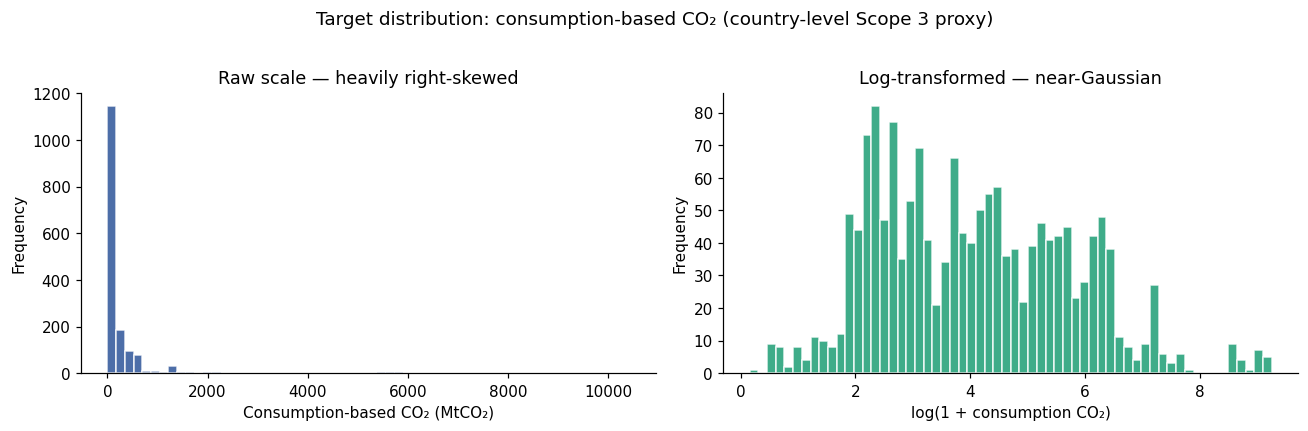

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].hist(panel['consumption_co2'], bins=60, color='#2E5599', alpha=0.85, edgecolor='white')
ax[0].set_xlabel('Consumption-based CO₂ (MtCO₂)'); ax[0].set_ylabel('Frequency')
ax[0].set_title('Raw scale — heavily right-skewed')

ax[1].hist(np.log1p(panel['consumption_co2']), bins=60, color='#1D9E75', alpha=0.85, edgecolor='white')
ax[1].set_xlabel('log(1 + consumption CO₂)'); ax[1].set_ylabel('Frequency')
ax[1].set_title('Log-transformed — near-Gaussian')
fig.suptitle('Target distribution: consumption-based CO₂ (country-level Scope 3 proxy)', y=1.02)
plt.tight_layout(); plt.show()

### 3.2 Scope 3 vs Scope 1 — where is the embedded carbon flowing?

For any country, `consumption_co2 - co2` is the **net imported embedded CO₂** — the part of Scope 3 that crosses national borders. Plotting these two against each other reveals at a glance which economies offshore their emissions (above the diagonal) versus which absorb others' (below).

### The Scope-3 trade identity and the log target

At country level, consumption-based emissions decompose by an accounting identity into domestic production plus net embedded trade:

$$\text{CO}_2^{\text{cons}} = \underbrace{\text{CO}_2^{\text{prod}}}_{\text{Scope 1}} + \underbrace{(\text{imports}-\text{exports of embedded CO}_2)}_{\texttt{trade\_co2}},$$

so `net_scope3 = consumption_co2 − co2 = trade_co2` is exactly the *cross-border* part of upstream Scope 3 — points above the $45^\circ$ line in the log–log scatter are net importers of embedded carbon.

Emissions span orders of magnitude across countries, so we model the **log target** $\tilde y = \log(1+y)$ (`log1p`, well-defined at $y=0$). This symmetrizes the heavy right skew toward approximate normality — matching the Gaussian likelihood used later — and turns multiplicative errors into additive ones, so squared error in log space behaves like a relative error. Predictions invert with $y=\exp(\tilde y)-1$ (`expm1`).

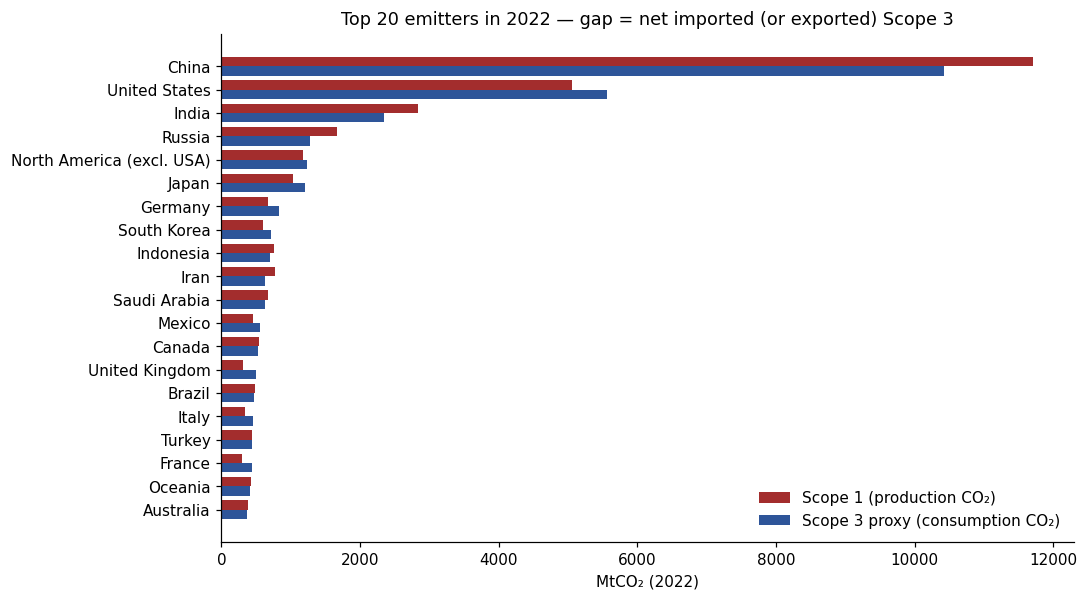

In [6]:
df22 = panel[panel['year']==2022].copy().reset_index(drop=True)
df22['net_scope3'] = df22['consumption_co2'] - df22['co2']

# Top emitters: production vs consumption
top = df22.nlargest(20, 'consumption_co2').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(top))
ax.barh(x - 0.2, top['co2'],              height=0.4, color='#A32D2D', label='Scope 1 (production CO₂)')
ax.barh(x + 0.2, top['consumption_co2'],  height=0.4, color='#2E5599', label='Scope 3 proxy (consumption CO₂)')
ax.set_yticks(x); ax.set_yticklabels(top['country']); ax.invert_yaxis()
ax.set_xlabel('MtCO₂ (2022)'); ax.legend(loc='lower right', frameon=False)
ax.set_title('Top 20 emitters in 2022 — gap = net imported (or exported) Scope 3')
plt.show()

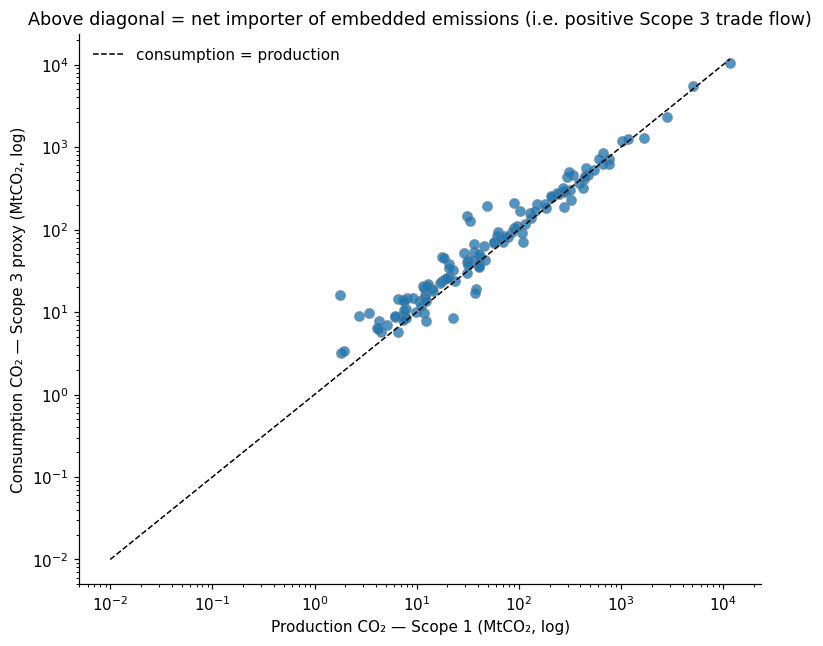

In [7]:
# Scatter with grid intensity colouring
fig, ax = plt.subplots(figsize=(8, 6.5))
sc = ax.scatter(df22['co2'], df22['consumption_co2'],
                c=df22['carbon_intensity_elec'] if 'carbon_intensity_elec' in df22 else None,
                s=44, cmap='RdYlGn_r', alpha=0.78, edgecolor='gray', linewidth=0.4)
mx = max(df22['co2'].max(), df22['consumption_co2'].max())
ax.plot([0.01, mx], [0.01, mx], 'k--', linewidth=1, label='consumption = production')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Production CO₂ — Scope 1 (MtCO₂, log)')
ax.set_ylabel('Consumption CO₂ — Scope 3 proxy (MtCO₂, log)')
ax.set_title('Above diagonal = net importer of embedded emissions (i.e. positive Scope 3 trade flow)')
if sc.get_array() is not None:
    plt.colorbar(sc, ax=ax, label='Grid carbon intensity (gCO₂/kWh)')
ax.legend(loc='upper left', frameon=False); plt.show()

### 3.3 Tier-n: the global power plant fleet (WRI)

Electricity generation is the dominant upstream contributor to most Scope 3 categories. The WRI database gives us 34,936 asset-level nodes with capacity, fuel type, and geocoordinates — the basis of our Tier-n layer.

### Capacity mix as compositional data (the simplex)

A country's fuel-capacity shares $\mathbf p=(p_{\text{coal}},p_{\text{gas}},\dots)$ obey $p_k\ge 0$ and $\sum_k p_k=1$, so $\mathbf p$ lives on the **probability simplex** $\Delta^{K-1}=\{\mathbf p\in\mathbb R^{K}_{\ge0}:\mathbf 1^{\!\top}\mathbf p=1\}$. Compositional data carry only *relative* information, and the unit-sum constraint induces **spurious negative correlation** between shares (Aitchison): raising one share must lower another. The principled descriptors are therefore log-ratios, e.g. the centred log-ratio $\operatorname{clr}(\mathbf p)_k=\log p_k-\tfrac1K\sum_j\log p_j$. Two scalar summaries of the mix recur below: the **Shannon entropy** $H(\mathbf p)=-\sum_k p_k\log p_k$ (maximal $=\log K$ at a uniform mix, $0$ for a single fuel) measures *diversity*, and the **Herfindahl index** $\mathrm{HHI}=\sum_k p_k^2\in[\tfrac1K,1]$ measures *concentration*. *In words:* the simplex is the space of pie-charts; entropy says how evenly the pie is split.

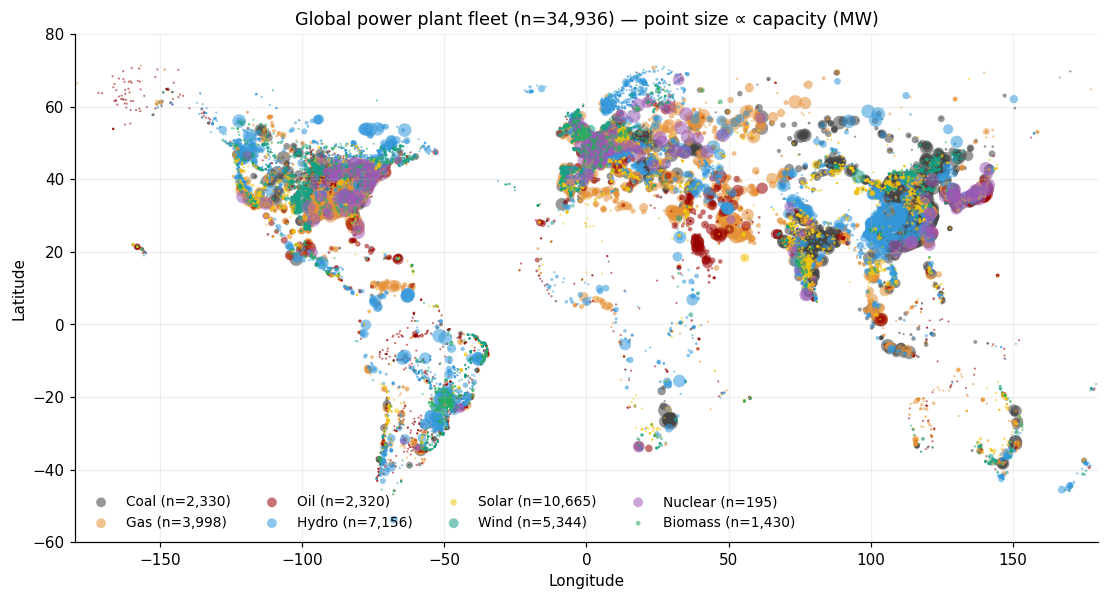

In [8]:
fuel_colors = {'Coal':'#444','Gas':'#E69138','Oil':'#990000','Hydro':'#3498DB',
               'Solar':'#F1C40F','Wind':'#16A085','Nuclear':'#9B59B6','Biomass':'#27AE60'}
fig, ax = plt.subplots(figsize=(12, 6))
for fuel, col in fuel_colors.items():
    sub = wri[wri['primary_fuel']==fuel].dropna(subset=['latitude','longitude','capacity_mw'])
    sizes = np.clip(sub['capacity_mw']/30, 2, 80)
    ax.scatter(sub['longitude'], sub['latitude'], s=sizes, c=col, alpha=0.55, label=f"{fuel} (n={len(sub):,})", edgecolor='none')
ax.set_xlim(-180, 180); ax.set_ylim(-60, 80)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Global power plant fleet (n={len(wri):,}) — point size ∝ capacity (MW)')
ax.legend(loc='lower left', ncol=4, fontsize=9, frameon=False); ax.grid(True, alpha=0.2)
plt.show()

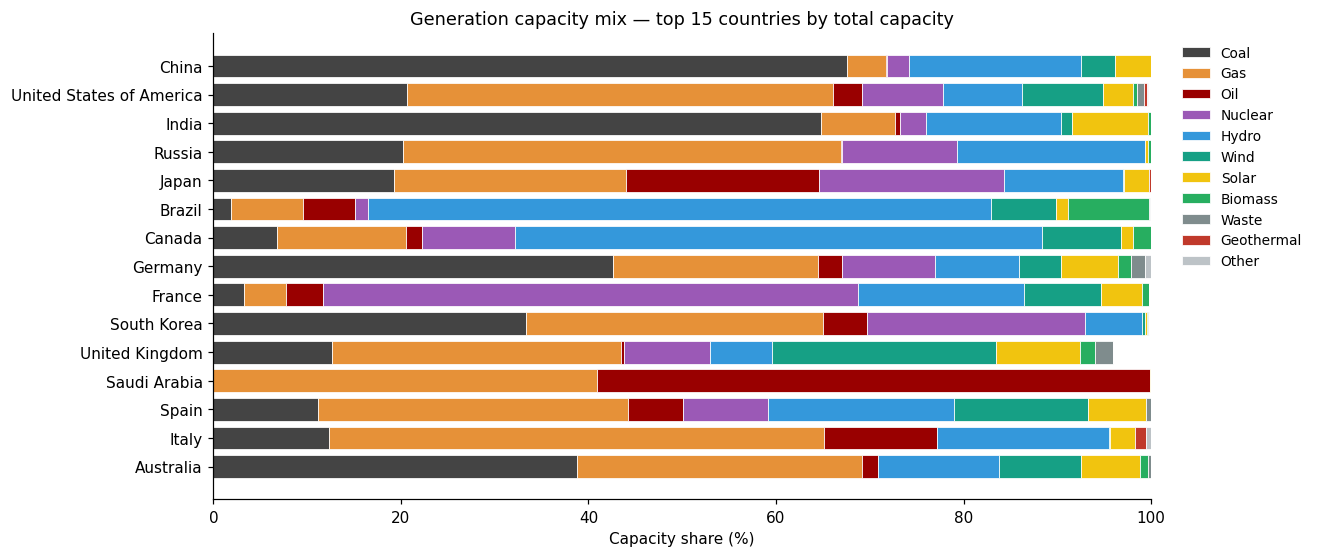

In [9]:
# Capacity mix per country (top 15)
top_cap = wri.groupby('country_long')['capacity_mw'].sum().nlargest(15).index
mix = wri[wri['country_long'].isin(top_cap)].pivot_table(
    index='country_long', columns='primary_fuel', values='capacity_mw', aggfunc='sum', fill_value=0)
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100
mix_pct = mix_pct.reindex(top_cap)

ordered_fuels = ['Coal','Gas','Oil','Nuclear','Hydro','Wind','Solar','Biomass','Waste','Geothermal','Other']
ordered_fuels = [f for f in ordered_fuels if f in mix_pct.columns]
fuel_cmap = {'Coal':'#444','Gas':'#E69138','Oil':'#990000','Nuclear':'#9B59B6','Hydro':'#3498DB',
             'Wind':'#16A085','Solar':'#F1C40F','Biomass':'#27AE60','Waste':'#7F8C8D','Geothermal':'#C0392B','Other':'#BDC3C7'}

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(mix_pct))
for f in ordered_fuels:
    ax.barh(np.arange(len(mix_pct)), mix_pct[f].values, left=bottom, color=fuel_cmap.get(f,'#999'), label=f, edgecolor='white', linewidth=0.5)
    bottom += mix_pct[f].values
ax.set_yticks(np.arange(len(mix_pct))); ax.set_yticklabels(mix_pct.index); ax.invert_yaxis()
ax.set_xlabel('Capacity share (%)')
ax.set_title('Generation capacity mix — top 15 countries by total capacity')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9); plt.show()

### 3.4 Grid carbon intensity is highly heterogeneous over time and space

This is the single strongest argument against spend-based estimation: the same dollar of electricity has wildly different carbon content depending on country and year. Activity-based models must respect this.

### Quantifying heterogeneity across space and time

Grid carbon intensity $I_{c,t}$ (gCO₂/kWh) ranges from ~$20$ (hydro/nuclear grids) to ~$900$ (coal grids). A scale-free dispersion measure is the **coefficient of variation** $\mathrm{CV}=\sigma/\mu$. To ask whether the variation is mostly *across* countries or *within* a country over time, apply the **law of total variance**
$$
\operatorname{Var}(I)=\underbrace{\mathbb E_c\!\big[\operatorname{Var}_t(I\mid c)\big]}_{\text{within-country (temporal)}}+\underbrace{\operatorname{Var}_c\!\big(\mathbb E_t[I\mid c]\big)}_{\text{between-country (cross-sectional)}} .
$$
A dominant *between* term means cross-sectional differences swamp year-to-year change — exactly the regime in which a **country-aware** model (one that conditions on which country a node is) beats a pooled regression. *In words:* total spread = average wiggle inside each country + spread of the country averages.

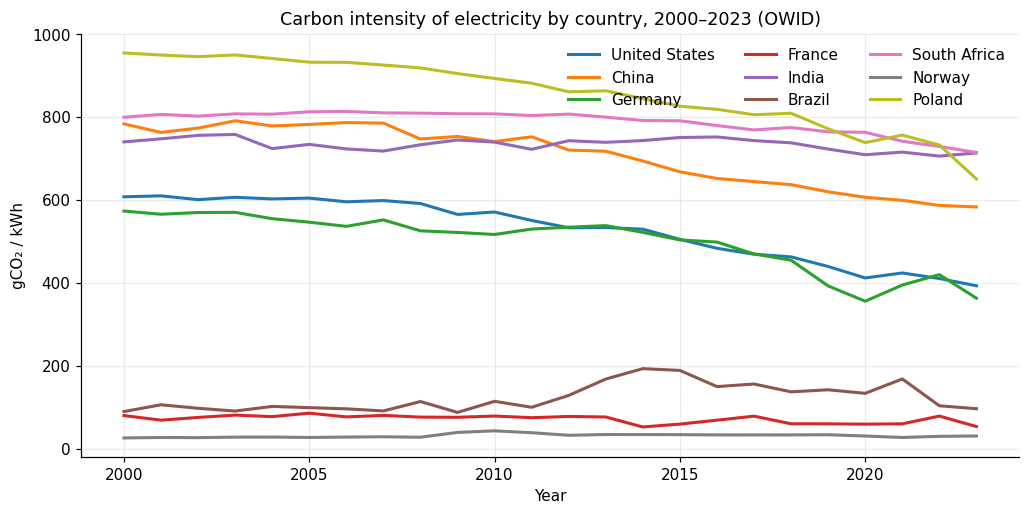

In [10]:
focus = ['United States','China','Germany','France','India','Brazil','South Africa','Norway','Poland']
fig, ax = plt.subplots(figsize=(11, 5))
for c in focus:
    sub = en[(en['country']==c) & (en['year']>=2000) & (en['year']<=2023)]
    if len(sub) > 5:
        ax.plot(sub['year'], sub['carbon_intensity_elec'], label=c, linewidth=2)
ax.set_xlabel('Year'); ax.set_ylabel('gCO₂ / kWh')
ax.set_title('Carbon intensity of electricity by country, 2000–2023 (OWID)')
ax.legend(loc='upper right', frameon=False, ncol=3); ax.grid(True, alpha=0.25); plt.show()

### 3.5 Trade-embedded CO₂ — direct evidence of multi-tier Scope 3 flows

OWID's `trade_co2` column directly measures the CO₂ embedded in imports minus exports. Countries with large positive values are *net consumers* of others' production emissions; large negatives are the production-side suppliers.

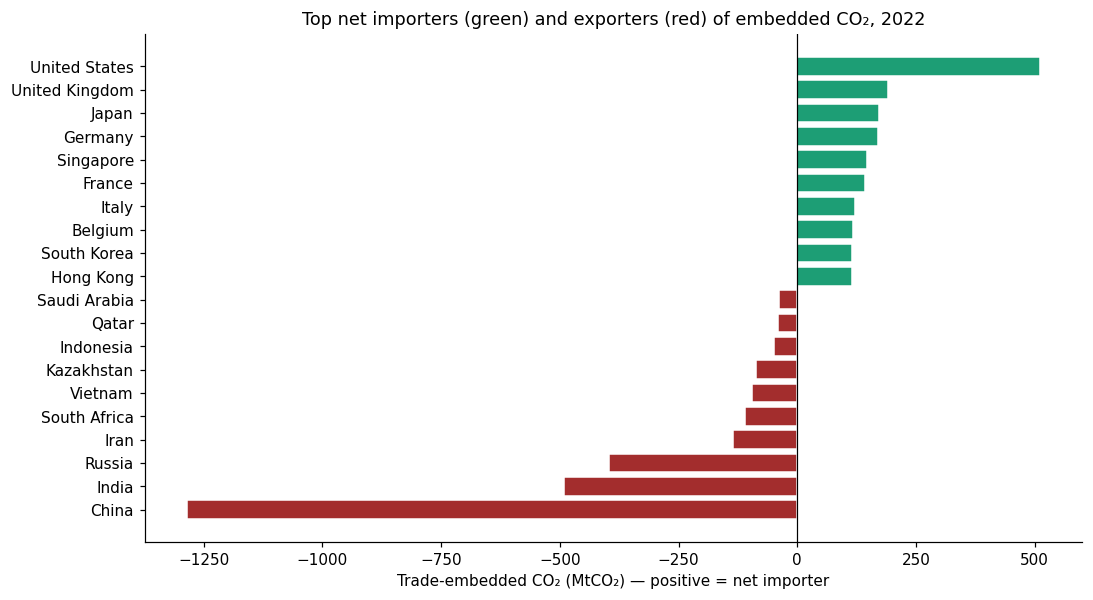

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
trade_df = df22.dropna(subset=['trade_co2']).sort_values('trade_co2').reset_index(drop=True)
top_imp = trade_df.tail(10).reset_index(drop=True)
top_exp = trade_df.head(10).reset_index(drop=True)
labels = list(top_exp['country']) + list(top_imp['country'])
values = list(top_exp['trade_co2'])  + list(top_imp['trade_co2'])
colors = ['#A32D2D']*10 + ['#1D9E75']*10
ax.barh(np.arange(20), values, color=colors, edgecolor='white')
ax.set_yticks(np.arange(20)); ax.set_yticklabels(labels)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Trade-embedded CO₂ (MtCO₂) — positive = net importer')
ax.set_title('Top net importers (green) and exporters (red) of embedded CO₂, 2022')
plt.show()

### 3.6 Feature engineering — merging the three sources

The merge produces a country-year panel with **30 features** spanning:

- **Production-side Scope 1 signals** (per-sector and total CO₂)
- **Macroeconomic** (population, GDP, per-capita and per-GDP intensities)
- **Grid composition** (carbon intensity of electricity, fuel shares)
- **Asset-fleet (Tier-n)** (capacity by fuel from WRI, geographic centre)

This represents the **activity-based, hybrid** input vector — *no monetary spend variable enters the prediction pipeline*.

### Engineered features: shares, intensities, imputation

The fleet features are **compositional**: each fuel's capacity share $s_f = C_f/\sum_{f'}C_{f'}\in[0,1]$ with $\sum_f s_f = 1$ (fossil share is their sum). The macro features are **intensities** — scale-normalizing ratios such as carbon intensity of GDP $\text{CO}_2/\text{GDP}$ and of electricity (gCO₂/kWh) — which make heterogeneous economies comparable. Missing entries are filled with the **column median**, robust to the heavy right skew (unlike the mean); this is appropriate here because missingness is driven mostly by reporting coverage rather than by the value itself.

In [12]:
# Merge in energy features (drop overlapping cols to avoid duplicates)
en_features = ['carbon_intensity_elec','fossil_share_elec','renewables_share_elec',
               'coal_share_elec','gas_share_elec','nuclear_share_elec','electricity_generation']
panel = panel.drop(columns=[c for c in en_features if c in panel.columns])
panel = panel.merge(en[['country','year']+en_features], on=['country','year'], how='left')

# Aggregate WRI plants → country-level Tier-n features
wri_country = wri.groupby('country_long').agg(
    n_plants=('gppd_idnr','count'),
    total_capacity_mw=('capacity_mw','sum'),
    mean_capacity_mw=('capacity_mw','mean'),
    coal_capacity_mw=('capacity_mw', lambda s: s[wri.loc[s.index,'primary_fuel']=='Coal'].sum()),
    gas_capacity_mw =('capacity_mw', lambda s: s[wri.loc[s.index,'primary_fuel']=='Gas'].sum()),
    oil_capacity_mw =('capacity_mw', lambda s: s[wri.loc[s.index,'primary_fuel']=='Oil'].sum()),
    renewable_capacity_mw=('capacity_mw', lambda s: s[wri.loc[s.index,'primary_fuel'].isin(['Solar','Wind','Hydro','Biomass','Geothermal'])].sum()),
    nuclear_capacity_mw=('capacity_mw', lambda s: s[wri.loc[s.index,'primary_fuel']=='Nuclear'].sum()),
    mean_lat=('latitude','mean'), mean_lon=('longitude','mean'),
).reset_index().rename(columns={'country_long':'country'})

for fuel in ['coal','gas','oil']:
    wri_country[f'{fuel}_share'] = wri_country[f'{fuel}_capacity_mw'] / wri_country['total_capacity_mw'].clip(lower=1)
wri_country['fossil_capacity_share'] = (wri_country['coal_capacity_mw'] + wri_country['gas_capacity_mw'] + wri_country['oil_capacity_mw']) / wri_country['total_capacity_mw'].clip(lower=1)

panel = panel.merge(wri_country, on='country', how='left')
panel = panel[panel['n_plants'].notna()].copy()

feature_cols = ['population','gdp','co2','co2_per_capita','co2_per_gdp',
                'coal_co2','gas_co2','oil_co2','cement_co2',
                'carbon_intensity_elec','fossil_share_elec','renewables_share_elec',
                'coal_share_elec','gas_share_elec','nuclear_share_elec','electricity_generation',
                'n_plants','total_capacity_mw','mean_capacity_mw',
                'coal_capacity_mw','gas_capacity_mw','oil_capacity_mw','renewable_capacity_mw','nuclear_capacity_mw',
                'coal_share','gas_share','oil_share','fossil_capacity_share','mean_lat','mean_lon']
target_col = 'consumption_co2'

# --- Sector-level targets: the six source-resolved production-CO₂ components.
#     They sum to production `co2` to within ~0.01% (verified on the panel), giving a
#     HARD accounting identity for the cross-resolution consistency loss (see §4.6).
sector_co2_cols = ['coal_co2','oil_co2','gas_co2','cement_co2','flaring_co2','other_industry_co2']
for c in sector_co2_cols:
    if c not in panel.columns:
        panel[c] = 0.0

keep = list(dict.fromkeys(['country','year', target_col, 'trade_co2', 'co2'] + feature_cols + sector_co2_cols))
panel_model = panel[keep].copy()
# IMPORTANT ordering: zero-fill the sector components FIRST. Four of them (coal/oil/gas/
# cement) are also model features; if median-filled there, the additive identity
# Sum(sectors)=production breaks for ~27% of rows. Zero is the correct value for an
# absent additive component and also a sensible feature value ("no such emissions").
for c in sector_co2_cols:
    panel_model[c] = panel_model[c].fillna(0.0)
for c in feature_cols:
    panel_model[c] = panel_model[c].fillna(panel_model[c].median())

print(f"Final panel: {panel_model.shape}  •  countries = {panel_model['country'].nunique()}  •  features = {len(feature_cols)}  •  sectors = {len(sector_co2_cols)}")

# Empirical check of the additive identity  Σ sector_co2 ≈ production co2
_chk = panel_model.assign(_s=panel_model[sector_co2_cols].sum(axis=1))
_rel = (_chk['_s'] - _chk['co2']).abs() / _chk['co2'].clip(lower=1e-6)
print(f"Accounting identity Σ(sectors) = production co2:  median rel. error = {_rel.median()*100:.3f}%  •  95th pct = {_rel.quantile(.95)*100:.3f}%")
panel_model.head()

Final panel: (1481, 36)  •  countries = 114  •  features = 30  •  sectors = 6
Accounting identity Σ(sectors) = production co2:  median rel. error = 0.000%  •  95th pct = 0.014%


,country,year,consumption_co2,trade_co2,co2,population,gdp,co2_per_capita,co2_per_gdp,coal_co2,...,renewable_capacity_mw,nuclear_capacity_mw,coal_share,gas_share,oil_share,fossil_capacity_share,mean_lat,mean_lon,flaring_co2,other_industry_co2
0,Albania,2010,6.580,1.763,4.817,2928731.0,2.674782e+10,1.645,0.180,0.447,...,1431.0,0.0,0.0,0.0,0.0,0.0,41.433675,19.832575,0.000,0.0
1,Albania,2011,6.984,1.809,5.175,2911499.0,2.743105e+10,1.778,0.189,0.586,...,1431.0,0.0,0.0,0.0,0.0,0.0,41.433675,19.832575,0.000,0.0
2,Albania,2012,6.571,1.641,4.930,2910003.0,2.781981e+10,1.694,0.177,0.686,...,1431.0,0.0,0.0,0.0,0.0,0.0,41.433675,19.832575,0.000,0.0
3,Albania,2013,6.516,1.170,5.346,2907571.0,2.809856e+10,1.839,0.190,0.846,...,1431.0,0.0,0.0,0.0,0.0,0.0,41.433675,19.832575,0.000,0.0
4,Albania,2014,6.501,0.429,6.072,2903748.0,2.859717e+10,2.091,0.212,1.096,...,1431.0,0.0,0.0,0.0,0.0,0.0,41.433675,19.832575,0.012,0.0


### 3.7 Correlation structure & missingness diagnostics

### Correlation and multicollinearity

The Pearson matrix $R_{ij}=\mathrm{Cov}(x_i,x_j)/(\sigma_i\sigma_j)\in[-1,1]$ exposes near-linear dependence among features. Population, GDP, and total CO₂ are strongly collinear, which inflates the variance of ordinary-least-squares coefficients because $X^\top X$ becomes ill-conditioned (small eigenvalues blow up $(X^\top X)^{-1}$). This is the statistical justification for the **Ridge** ($\ell_2$) baseline below, and for the tree/graph models, which are insensitive to collinearity.

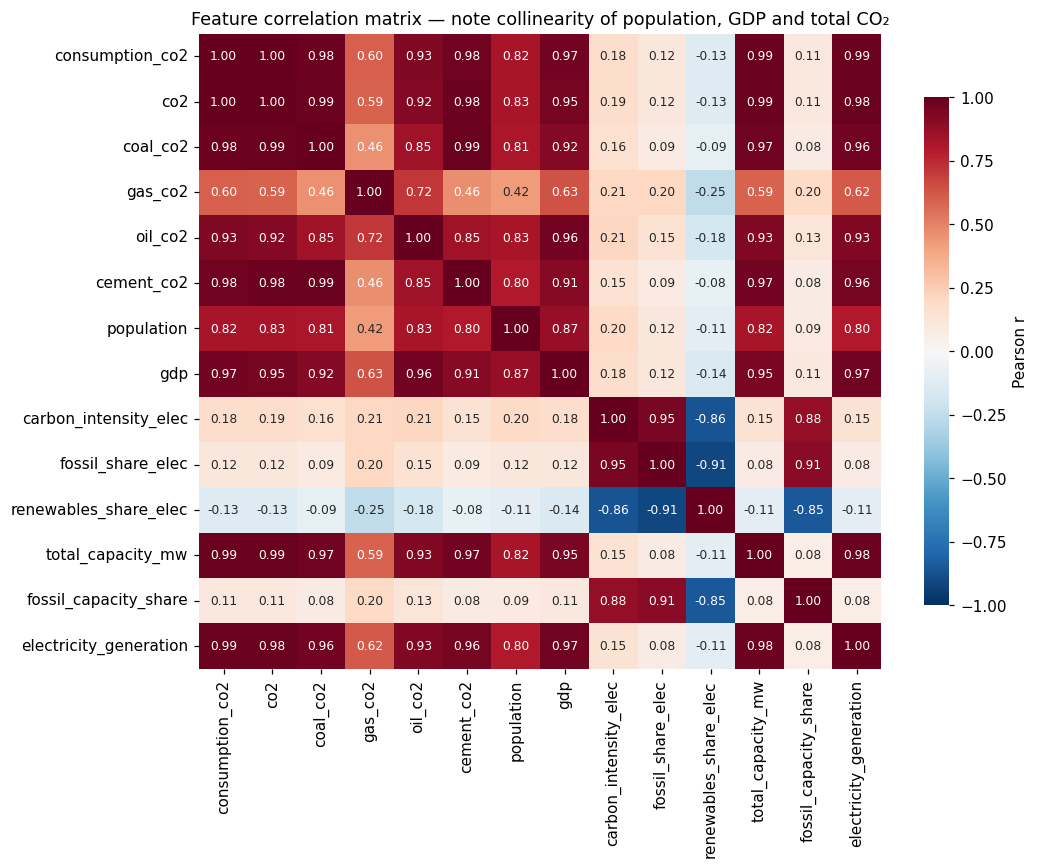

In [13]:
key_feats = ['consumption_co2','co2','coal_co2','gas_co2','oil_co2','cement_co2',
             'population','gdp','carbon_intensity_elec','fossil_share_elec','renewables_share_elec',
             'total_capacity_mw','fossil_capacity_share','electricity_generation']
corr = panel_model[key_feats].corr()

fig, ax = plt.subplots(figsize=(10, 7.5))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'shrink':0.8, 'label':'Pearson r'}, annot_kws={'size':8})
ax.set_title('Feature correlation matrix — note collinearity of population, GDP and total CO₂'); plt.show()

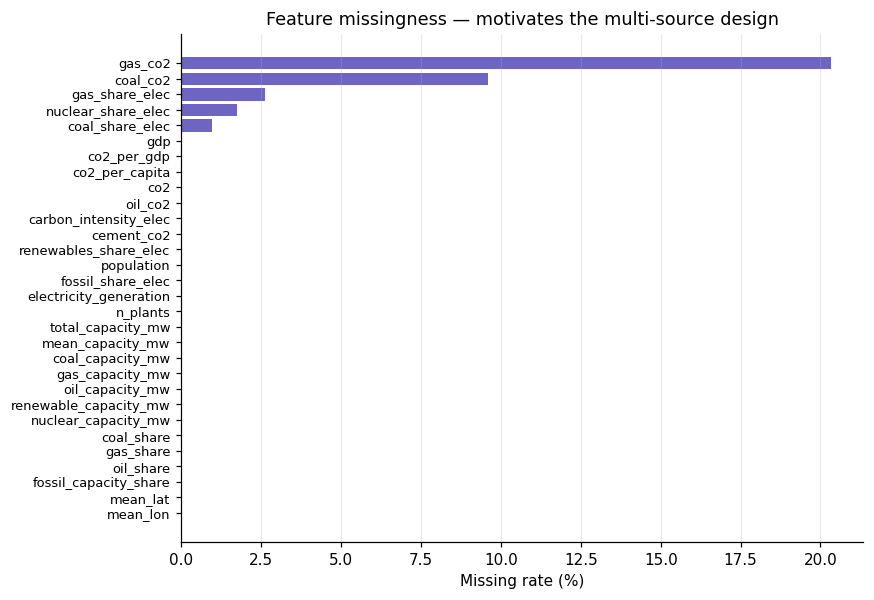

In [14]:
# Missingness profile (before imputation)
missing = panel[feature_cols].isna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.arange(len(missing)), missing.values*100, color='#534AB7', alpha=0.85)
ax.set_yticks(np.arange(len(missing))); ax.set_yticklabels(missing.index, fontsize=8.5); ax.invert_yaxis()
ax.set_xlabel('Missing rate (%)')
ax.set_title('Feature missingness — motivates the multi-source design')
ax.grid(True, axis='x', alpha=0.25); plt.show()

### 3.8 Sector-level exploratory analysis — the second resolution

The country EDA above treats each economy as a scalar. The model, however, also predicts the **six source-resolved components** of production CO₂ (coal, oil, gas, cement, flaring, other-industry). This subsection profiles that second resolution on the same real OWID panel: how the global mix evolves, how concentrated each economy's sources are, how the sectors co-move, how zero-inflated they are, and — critically — whether they satisfy the additive identity that the conservation loss (§4.6) relies on.

### Sector decomposition, compositional shares, and concentration

**Additive identity (linear algebra).** For every country-year the six components sum to production CO₂,
$$
e^{\text{prod}}_c=\sum_{k=1}^{6} e^{\text{sec}}_{c,k}\;=\;\big(S\,\mathbf e^{\text{sec}}\big)_c ,
$$
with $S\in\{0,1\}^{C\times K}$ the group-sum (incidence) matrix of §4.6.4. Panel (d) verifies this empirically at $R^2\approx1.0$ — it is the *ground-truth constraint* the model is later asked to reproduce out-of-sample.

**Shares on the simplex (statistics).** The sector **shares** $s_{c,k}=e^{\text{sec}}_{c,k}/e^{\text{prod}}_c$ satisfy $\sum_k s_{c,k}=1$, so each country is a point on $\Delta^{5}$. A country's **source diversity** is the Shannon entropy $H(\mathbf s_c)=-\sum_k s_{c,k}\log s_{c,k}$; a coal-monoculture has $H\!\to\!0$, a balanced mix $H\!\to\!\log 6$. Because shares are compositional, cross-sector association is read off **log emissions**, not shares (panel of correlations).

**Zero-inflation (and why $\log1p$).** Many $(c,k)$ cells are *exactly* zero — e.g. a country with no cement industry — so the marginal of $e^{\text{sec}}$ is a mixture of a point mass at $0$ and a continuous heavy-tailed part. The transform $y\mapsto\log(1+y)$ is finite at $0$ (unlike $\log$), maps the point mass to $0$, and stabilises the variance of the continuous part (§4.6.6) — which is why the sector target is $\log1p(e^{\text{sec}})$.

In [15]:
# Tidy sector frame from the six source-resolved components (real OWID data)
sector_long = panel_model.melt(
    id_vars=['country','year','co2','consumption_co2'],
    value_vars=sector_co2_cols, var_name='sector', value_name='sector_co2')
sector_long['sector'] = sector_long['sector'].str.replace('_co2','', regex=False)
sector_long['share']  = sector_long['sector_co2'] / sector_long['co2'].clip(lower=1e-6)
sector_order = ['coal','oil','gas','cement','flaring','other_industry']

print(f"Sector panel: {len(sector_long):,} country-year-sector rows  "
      f"({sector_long['country'].nunique()} countries × {sector_long['year'].nunique()} years × {len(sector_order)} sectors)")
g_share = sector_long.groupby('sector')['sector_co2'].sum(); g_share = g_share / g_share.sum()
summ = sector_long.groupby('sector')['sector_co2'].agg(mean='mean', median='median', max='max')
summ['zero_frac']  = sector_long.groupby('sector')['sector_co2'].apply(lambda s:(s<=0).mean())
summ['global_pct'] = (g_share*100)
print(summ.reindex(sector_order).round(2).to_string())

Sector panel: 8,886 country-year-sector rows  (114 countries × 13 years × 6 sectors)
                  mean  median      max  zero_frac  global_pct
sector                                                        
coal            115.11    3.51  8468.95       0.13       46.59
oil              69.16   16.67  1559.74       0.00       27.99
gas              45.80    7.89   828.79       0.22       18.53
cement           12.38    1.40   828.71       0.03        5.01
flaring           2.21    0.09    64.37       0.39        0.90
other_industry    2.43    0.00   198.09       0.64        0.98


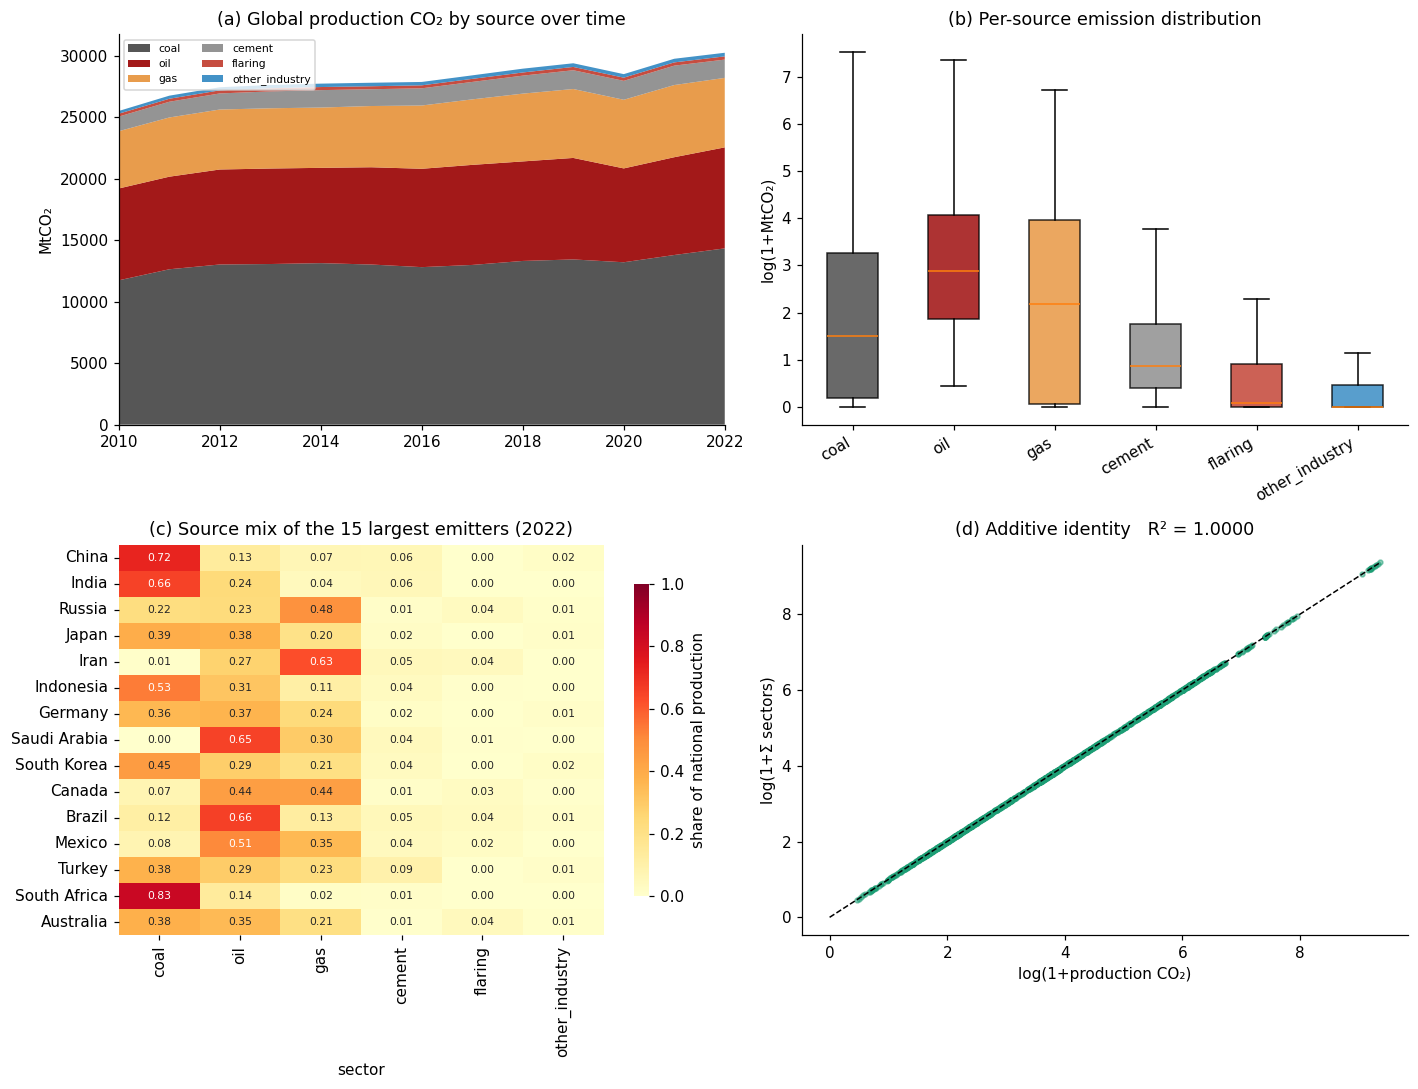

In [16]:
pal = {'coal':'#444','oil':'#990000','gas':'#E69138','cement':'#888',
       'flaring':'#C0392B','other_industry':'#2E86C1'}
fig, ax = plt.subplots(2, 2, figsize=(13, 10))

# (a) global production CO₂ by sector over time
gt = sector_long.groupby(['year','sector'])['sector_co2'].sum().unstack()[sector_order]
ax[0,0].stackplot(gt.index, [gt[s] for s in sector_order],
                  labels=sector_order, colors=[pal[s] for s in sector_order], alpha=0.9)
ax[0,0].set_title('(a) Global production CO₂ by source over time'); ax[0,0].set_ylabel('MtCO₂')
ax[0,0].legend(fontsize=7, loc='upper left', ncol=2); ax[0,0].margins(x=0)

# (b) per-sector emission distribution (log1p)
data = [np.log1p(sector_long.loc[sector_long.sector==s,'sector_co2']) for s in sector_order]
bp = ax[0,1].boxplot(data, patch_artist=True, showfliers=False)
for patch,s in zip(bp['boxes'], sector_order): patch.set_facecolor(pal[s]); patch.set_alpha(0.8)
ax[0,1].set_xticks(range(1, len(sector_order)+1)); ax[0,1].set_xticklabels(sector_order, rotation=30, ha='right')
ax[0,1].set_title('(b) Per-source emission distribution'); ax[0,1].set_ylabel('log(1+MtCO₂)')

# (c) sector-share heatmap for the 15 largest emitters (2022) — points on the simplex
top15 = sector_long[sector_long.year==2022].groupby('country')['sector_co2'].sum().nlargest(15).index
sh = (sector_long[(sector_long.year==2022) & (sector_long.country.isin(top15))]
      .pivot_table(index='country', columns='sector', values='share')[sector_order].loc[top15])
sns.heatmap(sh, ax=ax[1,0], cmap='YlOrRd', annot=True, fmt='.2f', vmin=0, vmax=1,
            cbar_kws={'label':'share of national production','shrink':0.8}, annot_kws={'size':7})
ax[1,0].set_title('(c) Source mix of the 15 largest emitters (2022)'); ax[1,0].set_ylabel('')

# (d) additive identity: Σ sectors == production CO₂
sums = sector_long.groupby(['country','year'])['sector_co2'].sum().reset_index(name='sec_sum')
chk = sums.merge(panel_model[['country','year','co2']].drop_duplicates(), on=['country','year'])
ax[1,1].scatter(np.log1p(chk['co2']), np.log1p(chk['sec_sum']), s=10, alpha=0.5, color='#1D9E75')
lim = [0, np.log1p(chk['co2']).max()]; ax[1,1].plot(lim, lim, 'k--', lw=1)
ax[1,1].set_xlabel('log(1+production CO₂)'); ax[1,1].set_ylabel('log(1+Σ sectors)')
ax[1,1].set_title(f'(d) Additive identity   R² = {r2_score(np.log1p(chk["co2"]), np.log1p(chk["sec_sum"])):.4f}')
plt.tight_layout(); plt.show()

Carbon-source diversity (Shannon entropy, nats) — mean=0.90  max(log6)=1.79


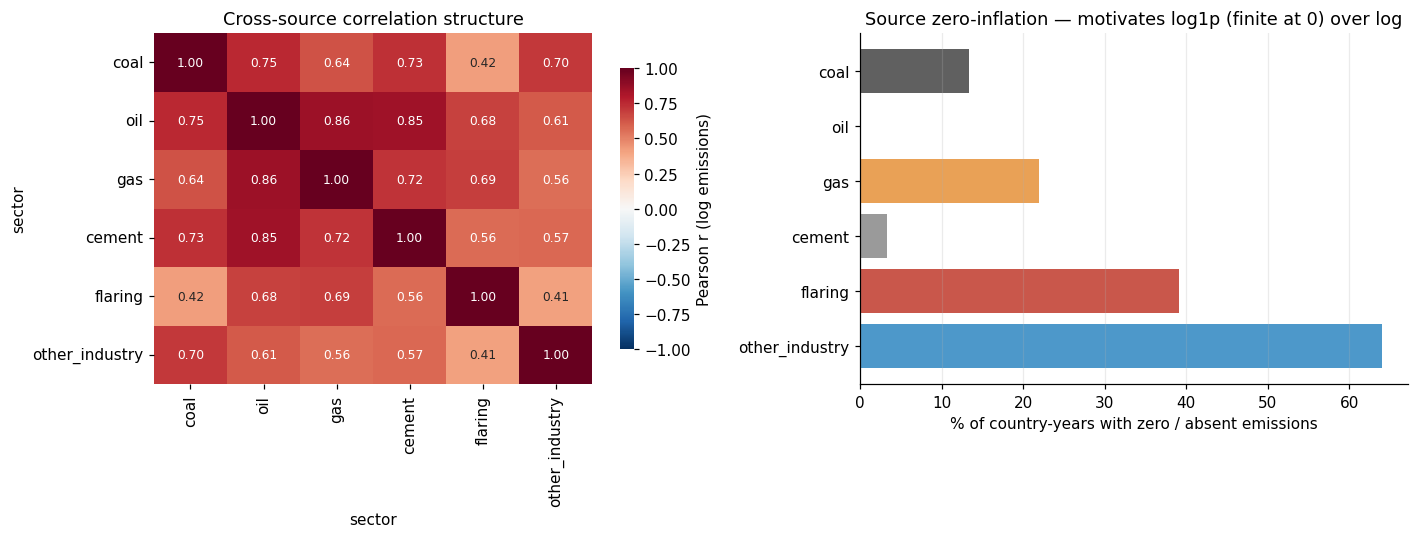

In [17]:
# Cross-sector correlation (on log emissions — the compositional-safe choice) + zero-inflation
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
wide = sector_long.pivot_table(index=['country','year'], columns='sector', values='sector_co2')[sector_order]
cc = np.log1p(wide).corr()
sns.heatmap(cc, ax=ax[0], annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'shrink':0.8,'label':'Pearson r (log emissions)'}, annot_kws={'size':8})
ax[0].set_title('Cross-source correlation structure')

zf = (wide<=0).mean().reindex(sector_order)
ax[1].barh(np.arange(len(sector_order)), zf.values*100, color=[pal[s] for s in sector_order], alpha=0.85)
ax[1].set_yticks(np.arange(len(sector_order))); ax[1].set_yticklabels(sector_order); ax[1].invert_yaxis()
ax[1].set_xlabel('% of country-years with zero / absent emissions')
ax[1].set_title('Source zero-inflation — motivates log1p (finite at 0) over log')
ax[1].grid(True, axis='x', alpha=0.25)

# Carbon-source diversity (Shannon entropy on shares), latest year
shares = wide.div(wide.sum(axis=1).clip(lower=1e-9), axis=0)
ent = -(shares*np.log(shares.replace(0,np.nan))).sum(axis=1)
print(f"Carbon-source diversity (Shannon entropy, nats) — mean={ent.mean():.2f}  max(log6)={np.log(6):.2f}")
plt.tight_layout(); plt.show()

### 3.9 A third resolution — demand sectors and subsectors (real CAIT data)

The source axis of §3.8 (coal / oil / gas / …) answers *what fuel* was burned. Policy, however, acts on *who demands* the energy — power, transport, industry, buildings. We add this second, orthogonal axis from a real, peer-reviewed source: **Climate Watch / CAIT** (distributed via OWID), which reports per-country, per-year CO₂ for the economic demand sectors and carries a genuine two-level hierarchy that maps directly onto the taxonomy of interest:

| Demand sector (this work) | Real CAIT column(s) | Hierarchy level |
|---|---|---|
| Electricity & Heat | *Electricity & Heat* | subsector (of Energy) |
| Transport | *Transport* | subsector (of Energy) |
| Buildings | *Building* | subsector (of Energy) |
| Industry & Manufacturing | *Manufacturing & Construction* (+ *Industry* processes) | subsector / sector |
| Other Energy Industries | *Other Fuel Combustion* + *Fugitive Emissions* | subsector (of Energy) |

The six **Energy** subsectors sum exactly to the **Energy** sector, and *Energy + Industrial-processes* sums exactly to the **national** total — two real additive identities (verified below to a median of 0.000 %) that extend the country→source-sector tree of §3.8 into a full **country → sector → subsector** hierarchy.

**Data-honesty note.** CAIT resolves emissions to the demand-subsector level (electricity, transport, buildings, …) for **1990–2016**, so this layer overlaps the modelling panel on 2010–2016. The still-finer splits in the broader taxonomy — gasoline vs. diesel within transport, thermal vs. metallurgical coal, residential vs. commercial buildings — are **not available from any single open country-year dataset**; they exist only in asset-level inventories such as **Climate TRACE**, which is the documented route for a future fourth resolution rather than anything synthesised here.

### A nested hierarchy of incidence operators

The three resolutions form a tree linked by two **incidence (group-sum) matrices**, generalising the operator $S$ of §4.6.4. Let $\mathbf e_{\text{sub}}\in\mathbb R^{K}$ hold the demand-subsector emissions. One operator aggregates subsectors into sectors, a second aggregates sectors into the national scalar:
$$
\mathbf e_{\text{sector}} = S_2\,\mathbf e_{\text{sub}},\qquad
e_{\text{nation}} = S_1\,\mathbf e_{\text{sector}} = S_1 S_2\,\mathbf e_{\text{sub}},
$$
with $S_2\in\{0,1\}^{|\text{sector}|\times K}$ and $S_1\in\{0,1\}^{1\times|\text{sector}|}$. **In words:** summing up the tree is just repeated multiplication by $0/1$ group-sum matrices, so a model that predicts the *leaves* (subsectors) can reconstruct every internal node — Energy, national — by pure linear algebra. Whether independently-trained leaves actually satisfy $S_2\hat{\mathbf e}_{\text{sub}}=\hat{\mathbf e}_{\text{sector}}$ out-of-sample is the **coherence** property tested in §8.8. As before, shares $s_k=e_k/\sum_j e_j$ live on a simplex and source diversity is the Shannon entropy $H(\mathbf s)=-\sum_k s_k\log s_k$.

In [18]:
# === Real demand-sector / subsector layer: Climate Watch / CAIT (via OWID) ===========
cait_url = ("https://raw.githubusercontent.com/owid/owid-datasets/master/datasets/"
            "CO2%20emissions%20by%20sector%20(CAIT%2C%202020)/"
            "CO2%20emissions%20by%20sector%20(CAIT%2C%202020).csv")
cait_raw = pd.read_csv(cait_url)
cait_map = {'Electricity & Heat (CAIT)':'electricity_heat', 'Transport (CAIT)':'transport',
            'Building (CAIT)':'buildings', 'Manufacturing & Construction (CAIT)':'manufacturing',
            'Fugitive Emissions (CAIT)':'fugitive', 'Other Fuel Combustion (CAIT)':'other_fuel',
            'Industry (CAIT)':'industry_processes', 'Energy (CAIT)':'energy_total',
            'Total excluding LUCF (CAIT)':'national_total'}
cait = cait_raw.rename(columns={'Entity':'country', 'Year':'year', **cait_map})
demand_subsectors = ['electricity_heat','transport','buildings','manufacturing','fugitive','other_fuel']
cait = cait[['country','year'] + demand_subsectors + ['industry_processes','energy_total','national_total']]
cait = cait[cait['year'].between(2010, 2022)].copy()
for c in demand_subsectors + ['industry_processes']:
    cait[c] = cait[c].fillna(0.0)          # a missing additive component ≈ 0

# Two real additive identities — the hierarchy the predictions must respect (§8.8)
id_energy = ((cait[demand_subsectors].sum(1) - cait['energy_total']).abs() / cait['energy_total'].clip(lower=1e-6))
id_nation = (((cait['energy_total'] + cait['industry_processes']) - cait['national_total']).abs() / cait['national_total'].clip(lower=1e-6))
print(f"CAIT demand sectors: {cait['country'].nunique()} countries × {sorted(cait['year'].unique())[0]}–{sorted(cait['year'].unique())[-1]}")
print(f"Hierarchy identity  Energy = Σ 6 subsectors      :  median rel. error = {id_energy.median()*100:.3f}%")
print(f"Hierarchy identity  National = Energy + Industry :  median rel. error = {id_nation.median()*100:.3f}%")

# Merge onto the modelling panel (country-years with BOTH activity features and CAIT)
demand_merged = panel_model.merge(cait, on=['country','year'], how='inner')
demand_long = demand_merged.melt(id_vars=['country','year','energy_total','national_total'],
                                 value_vars=demand_subsectors, var_name='subsector', value_name='sub_co2')
print(f"Merged (panel ∩ CAIT): {len(demand_merged)} country-years, "
      f"{demand_merged['country'].nunique()} countries, years {sorted(demand_merged['year'].unique())}")

CAIT demand sectors: 195 countries × 2010–2016
Hierarchy identity  Energy = Σ 6 subsectors      :  median rel. error = 0.000%
Hierarchy identity  National = Energy + Industry :  median rel. error = 0.000%
Merged (panel ∩ CAIT): 790 country-years, 113 countries, years [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]


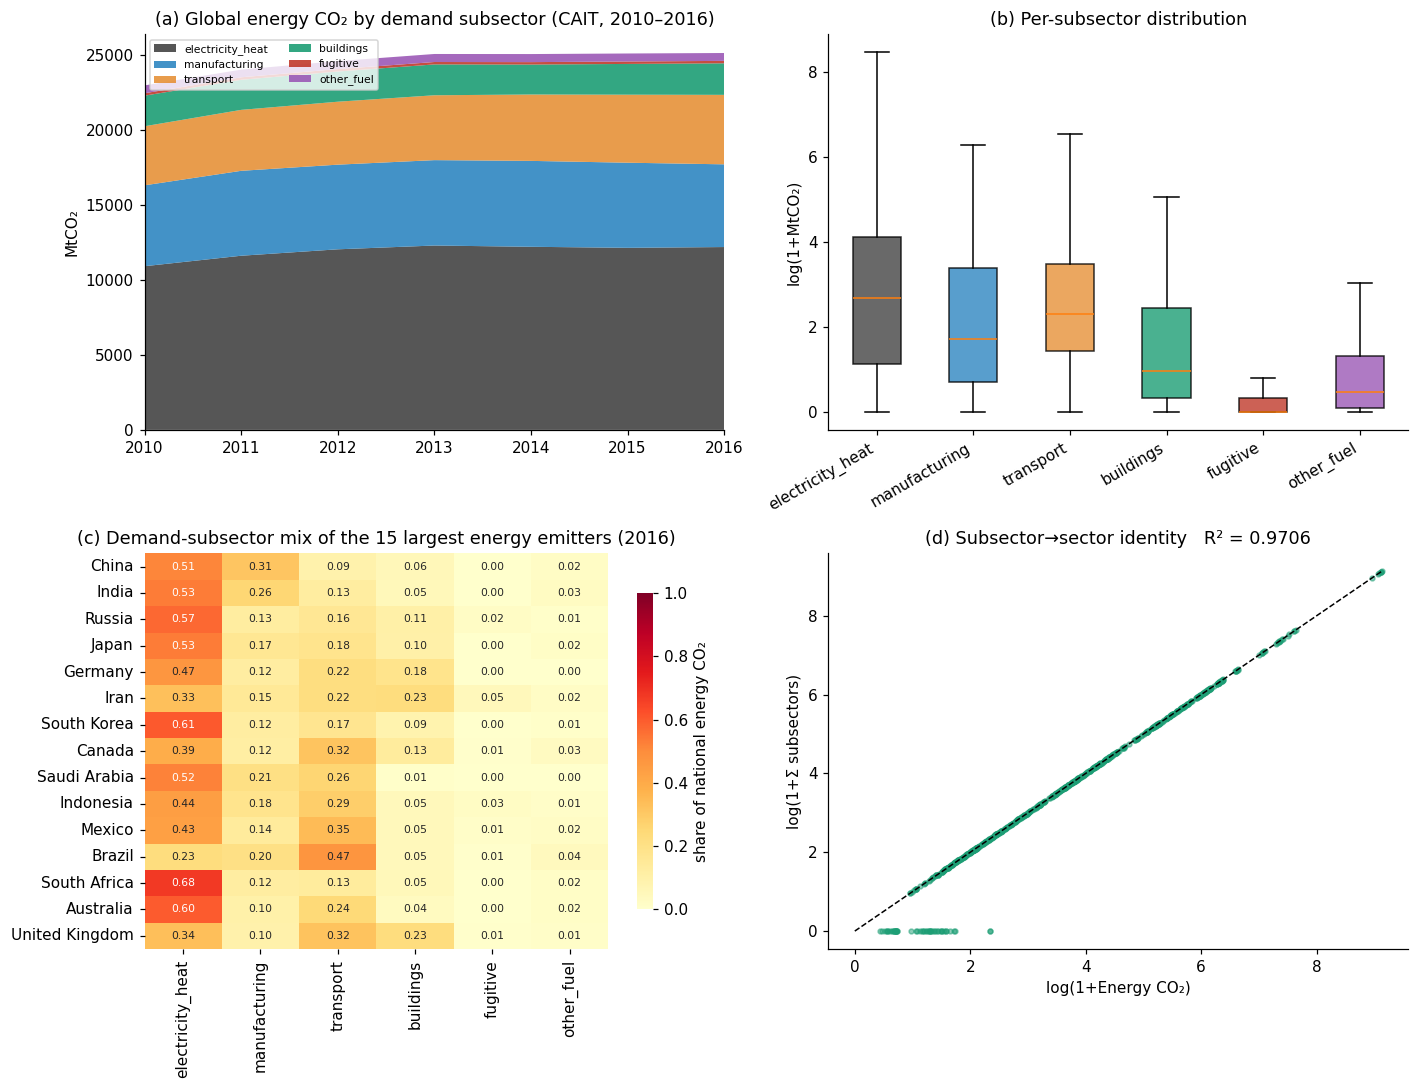

In [19]:
sub_order = ['electricity_heat','manufacturing','transport','buildings','fugitive','other_fuel']
sub_pal = {'electricity_heat':'#444','manufacturing':'#2E86C1','transport':'#E69138',
           'buildings':'#1D9E75','fugitive':'#C0392B','other_fuel':'#9B59B6'}
fig, ax = plt.subplots(2, 2, figsize=(13, 10))

# (a) global energy CO₂ by demand subsector over time
gt = demand_long.groupby(['year','subsector'])['sub_co2'].sum().unstack()[sub_order]
ax[0,0].stackplot(gt.index, [gt[s] for s in sub_order], labels=sub_order,
                  colors=[sub_pal[s] for s in sub_order], alpha=0.9)
ax[0,0].set_title('(a) Global energy CO₂ by demand subsector (CAIT, 2010–2016)'); ax[0,0].set_ylabel('MtCO₂')
ax[0,0].legend(fontsize=7, loc='upper left', ncol=2); ax[0,0].margins(x=0)

# (b) per-subsector distribution
data = [np.log1p(demand_long.loc[demand_long.subsector==s,'sub_co2']) for s in sub_order]
bp = ax[0,1].boxplot(data, patch_artist=True, showfliers=False)
for patch,s in zip(bp['boxes'], sub_order): patch.set_facecolor(sub_pal[s]); patch.set_alpha(0.8)
ax[0,1].set_xticks(range(1,len(sub_order)+1)); ax[0,1].set_xticklabels(sub_order, rotation=30, ha='right')
ax[0,1].set_title('(b) Per-subsector distribution'); ax[0,1].set_ylabel('log(1+MtCO₂)')

# (c) demand-subsector share mix of the 15 largest energy emitters (2016) — the simplex
d16 = demand_merged[demand_merged.year==2016].set_index('country')
top15 = d16.nlargest(15, 'energy_total').index
sh = d16.loc[top15, sub_order].div(d16.loc[top15,'energy_total'].clip(lower=1e-6), axis=0)
sns.heatmap(sh, ax=ax[1,0], cmap='YlOrRd', annot=True, fmt='.2f', vmin=0, vmax=1,
            cbar_kws={'label':'share of national energy CO₂','shrink':0.8}, annot_kws={'size':7})
ax[1,0].set_title('(c) Demand-subsector mix of the 15 largest energy emitters (2016)'); ax[1,0].set_ylabel('')

# (d) hierarchy identity: Σ subsectors == Energy
xo = np.log1p(demand_merged['energy_total']); yo = np.log1p(demand_merged[sub_order].sum(1))
ax[1,1].scatter(xo, yo, s=10, alpha=0.5, color='#1D9E75'); lim=[0, xo.max()]; ax[1,1].plot(lim,lim,'k--',lw=1)
ax[1,1].set_xlabel('log(1+Energy CO₂)'); ax[1,1].set_ylabel('log(1+Σ subsectors)')
ax[1,1].set_title(f'(d) Subsector→sector identity   R² = {r2_score(xo, yo):.4f}')
plt.tight_layout(); plt.show()

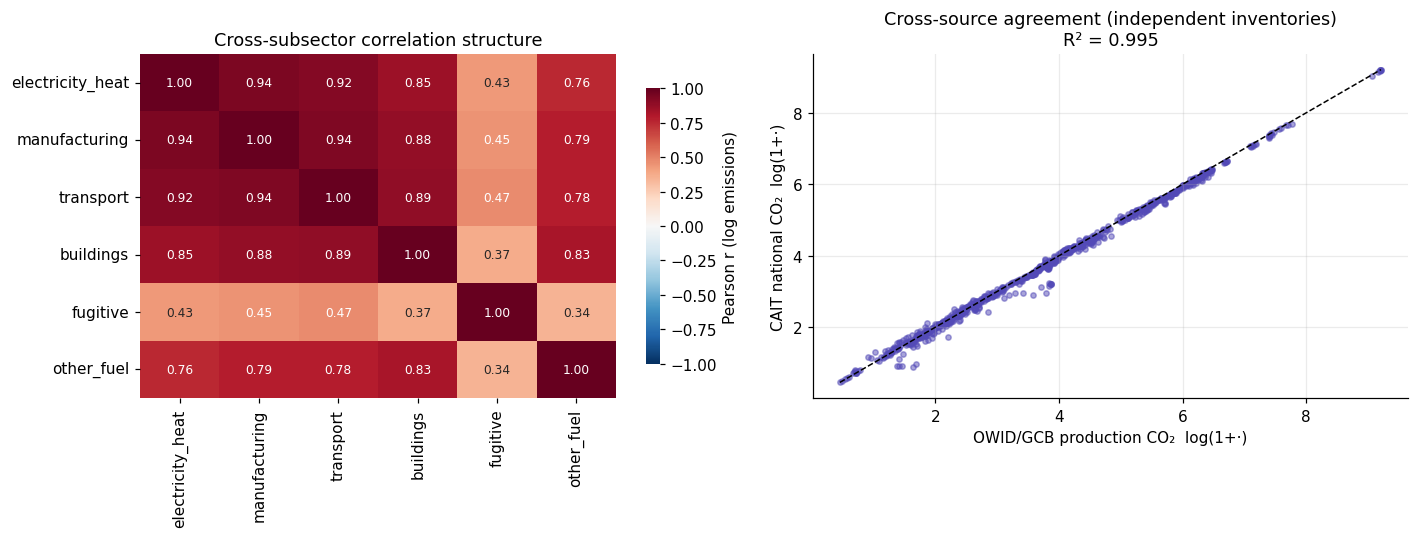

Demand-mix diversity (Shannon entropy, nats) — mean=1.14  max(log6)=1.79


In [20]:
# Cross-subsector correlation (log emissions) + cross-source validation (CAIT vs OWID national CO₂)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
wide = demand_merged.set_index(['country','year'])[sub_order]
cc = np.log1p(wide).corr()
sns.heatmap(cc, ax=ax[0], annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'shrink':0.8,'label':'Pearson r (log emissions)'}, annot_kws={'size':8})
ax[0].set_title('Cross-subsector correlation structure')

# independent real cross-check: CAIT national CO₂ vs OWID production CO₂ (two methodologies)
both = demand_merged[['national_total','co2']].dropna()
ax[1].scatter(np.log1p(both['co2']), np.log1p(both['national_total']), s=12, alpha=0.5, color='#534AB7')
rl=[np.log1p(both['co2']).min(), np.log1p(both['co2']).max()]; ax[1].plot(rl, rl, 'k--', lw=1)
ax[1].set_xlabel('OWID/GCB production CO₂  log(1+·)'); ax[1].set_ylabel('CAIT national CO₂  log(1+·)')
ax[1].set_title(f'Cross-source agreement (independent inventories)\nR² = {r2_score(np.log1p(both["co2"]), np.log1p(both["national_total"])):.3f}')
ax[1].grid(alpha=0.25); plt.tight_layout(); plt.show()

# carbon-demand diversity (Shannon entropy of the subsector mix)
shares = wide.div(wide.sum(1).clip(lower=1e-9), axis=0)
ent = -(shares*np.log(shares.replace(0, np.nan))).sum(1)
print(f"Demand-mix diversity (Shannon entropy, nats) — mean={ent.mean():.2f}  max(log6)={np.log(6):.2f}")

## 4. Mathematical model

This is the proposal's methodological core. The model is specified rigorously so that every component is publishable in its own right.

### 4.1 Problem definition

Let the multi-tier supplier graph be a typed directed graph
$$
G \;=\; (V,\; E,\; R,\; \tau)
$$
where $V$ is the union of node types $\{\text{country},\, \text{sector},\, \text{plant}\}$, $E$ is the set of typed directed edges (`plant→sector`, `sector→country`, `country→country`), $R$ is the set of relation types, and $\tau : V \to \mathbb{N}$ is the tier-depth function. Reporting nodes (Tier 0) are countries; Tier-n nodes are individual power plants.

Each node $v$ carries a feature vector $\mathbf{x}_v \in \mathbb{R}^{d_v}$, and each edge $(u,v)$ carries a flow weight $w(u,v) \in \mathbb{R}_+$ (mass, capacity or proximity).

A subset $D \subseteq V_{\text{country}}$ has observed direct emissions $y_v^\star$ (the supervised signal: country-level consumption CO₂).

### 4.2 Tier-aware heterogeneous message passing

Node representations are updated by $L$ layers of the Heterogeneous Graph Transformer (Hu et al., 2020), augmented with a learned tier-distance bias. At layer $\ell$, the message from neighbour $u$ to node $v$ under relation $r$ is

$$
m_{u\to v}^{(\ell,r)} \;=\; \alpha_{u,v}^{(\ell,r)} \cdot W_{\text{msg}}^{(\ell,r)}\, h_u^{(\ell-1)}
$$

with attention weights

$$
\alpha_{u,v}^{(\ell,r)} \;=\; \mathrm{softmax}_u\!\Bigl\{\,
\frac{(W_Q^{(\ell,r)} h_v^{(\ell-1)}) \cdot (W_K^{(\ell,r)} h_u^{(\ell-1)})}{\sqrt{d_k}}
\;+\; \beta\, \log w(u,v)
\;+\; \gamma\, \varphi\bigl(\tau(u),\tau(v)\bigr)
\,\Bigr\}.
$$

Here $\varphi(\cdot)$ is a learned scalar embedding of **tier distance**, allowing the network to learn how much signal to propagate from each upstream layer rather than treating all hops uniformly.

### 4.3 Multi-task heads with heteroscedastic Gaussian likelihood

For every country node $v$,

$$
\mu_v \;=\; f_\mu(h_v^{(L)}), \qquad
\log \sigma_v^2 \;=\; f_{\sigma}(h_v^{(L)}),
\qquad
y_v \mid h_v \;\sim\; \mathcal{N}(\mu_v,\, \sigma_v^2).
$$

The supervised negative log-likelihood is

$$
\mathcal{L}_{\text{NLL}} \;=\; \frac{1}{|D|} \sum_{v \in D} \frac{(y_v^\star - \mu_v)^2}{2\,\sigma_v^2} + \frac{1}{2}\log \sigma_v^2.
$$

### 4.4 Physics-informed regularisation

To prevent unphysical predictions, we add a soft non-negativity penalty (emissions cannot be negative):

$$
\mathcal{L}_{\text{phys}} \;=\; \frac{1}{|V_{\text{country}}|} \sum_v \bigl[\,\mathrm{ReLU}(-\mu_v)\bigr]^2.
$$

A more elaborate mass-balance term (full Leontief-style conservation across the upstream graph) is part of the planned PhD extension; the current implementation uses the non-negativity term as a baseline.

### 4.5 Total loss and Bayesian inference

The training objective is

$$
\mathcal{L} \;=\; \mathcal{L}_{\text{NLL}} \;+\; \lambda\, \mathcal{L}_{\text{phys}} \;+\; \eta\, \mathrm{KL}\bigl(q_\phi(\theta) \,\Vert\, p(\theta)\bigr),
$$

where the last term is an L2 weight decay acting as a Gaussian prior on the parameters. Epistemic uncertainty is captured by Monte-Carlo dropout (Gal & Ghahramani, 2016) at inference: dropout layers are kept active and $T$ forward passes produce a posterior sample
$$
\bigl\{\,\hat{y}_v^{(t)}\,\bigr\}_{t=1}^{T} \;\longrightarrow\; \mathbb{E}[y_v], \;\;\mathrm{Var}[y_v].
$$


### 4.6 Extension — predicting country **and** sector emissions simultaneously

The model of §4.1–§4.5 supervises only country nodes. We now promote the **sector tier to a first-class prediction target**, so a single forward pass returns emissions at two resolutions. This subsection gives the full mathematics — the *linear algebra* of the aggregation operator, the *calculus* of the gradients, and the *statistics* of the dual likelihood — and defines every term as it is introduced.

#### 4.6.1 Two label sets (multi-task learning)

We now hold two supervised sets,
$$
D_c \subseteq V_{\text{country}},\quad y^\star_c \;=\; \text{consumption CO}_2\ (\text{Scope\,3}),
\qquad
D_s \subseteq V_{\text{sector}},\quad y^\star_k \;=\; \text{source-resolved production CO}_2 .
$$
**In words.** The *country head* answers "how much carbon does this economy ultimately consume, including imports?"; the *sector head* answers "how is each economy's production split across coal, oil, gas, cement, flaring and other industry?" They are learned **jointly** under *hard parameter sharing*: the $L{=}3$ HGT layers produce one shared embedding $h_v^{(L)}$ for every node, and two lightweight head networks read off the two targets. Sharing the trunk lets the sector signal regularise the country estimate and vice-versa — the essence of multi-task learning.

#### 4.6.2 Dual heteroscedastic Gaussian likelihood (statistics)

Each resolution gets its own *heteroscedastic* Gaussian head (cf. §4.3):
$$
y_c \mid h_c \sim \mathcal N\!\big(\mu_c,\ \sigma_c^2\big),\qquad
y_k \mid h_k \sim \mathcal N\!\big(\mu_k,\ \sigma_k^2\big),
\qquad
\mu_\bullet=f_\mu(h_\bullet^{(L)}),\ \ \log\sigma_\bullet^2=f_\sigma(h_\bullet^{(L)}).
$$
*Heteroscedastic* (Greek *hetero* = different, *skedasis* = dispersion) means the variance is **not constant** — it is predicted per node, so the network can be confident about Germany's gas emissions yet unsure about a data-sparse flaring entry. The variance $\sigma^2$ here is **aleatoric** uncertainty (irreducible noise in the data); the **epistemic** uncertainty (what the model does not know) is recovered separately by MC-dropout in §4.5. The two supervised objectives are the standard Gaussian negative log-likelihoods (NLL),
$$
\mathcal L^{c}_{\text{NLL}}=\frac1{|D_c|}\!\sum_{v\in D_c}\!\Big[\tfrac{(y^\star_v-\mu_v)^2}{2\sigma_v^2}+\tfrac12\log\sigma_v^2\Big],
\qquad
\mathcal L^{s}_{\text{NLL}}=\frac1{|D_s|}\!\sum_{k\in D_s}\!\Big[\tfrac{(y^\star_k-\mu_k)^2}{2\sigma_k^2}+\tfrac12\log\sigma_k^2\Big].
$$
The NLL is the negative logarithm of the Gaussian density; minimising it is *maximum-likelihood estimation* (MLE) — choosing parameters that make the observed emissions most probable.

#### 4.6.3 Why the likelihood self-calibrates (calculus)

Let $s_v=\log\sigma_v^2$ and differentiate one NLL term. Using $\frac{\partial}{\partial\mu}\tfrac12(y-\mu)^2\sigma^{-2}=-(y-\mu)\sigma^{-2}$ and $\frac{\partial}{\partial s}e^{-s}=-e^{-s}$,
$$
\frac{\partial \mathcal L_{\text{NLL}}}{\partial \mu_v}=\frac{\mu_v-y^\star_v}{\sigma_v^2}
\quad(\textbf{precision-weighted residual}),
\qquad
\frac{\partial \mathcal L_{\text{NLL}}}{\partial s_v}=\frac12\!\Big(1-\frac{(y^\star_v-\mu_v)^2}{\sigma_v^2}\Big).
$$
**Reading the calculus.** The mean-gradient is the error scaled by the **precision** $1/\sigma_v^2$, so noisy nodes pull the weights less. Setting the variance-gradient to zero gives the stationary point $\sigma_v^2=(y^\star_v-\mu_v)^2$: at the optimum the predicted variance equals the squared error — precisely the property that makes the predictive intervals *calibrated* (§8.2).

#### 4.6.4 The aggregation operator $S$ (linear algebra)

The six sector components of a country are an **exact additive decomposition** of its production CO$_2$ (verified on the panel to a median relative error of $0.00\%$):
$$
e^{\text{prod}}_c=\sum_{k:\,c(k)=c} e^{\text{sec}}_k .
$$
Stack the per-sector emissions in $\mathbf e^{\text{sec}}\in\mathbb R^{K}$ and define the **selection / incidence matrix** $S\in\{0,1\}^{C\times K}$ with $S_{ck}=1$ iff sector node $k$ belongs to country $c$. The whole decomposition is then a single matrix–vector product,
$$
\mathbf e^{\text{prod}} \;=\; S\,\mathbf e^{\text{sec}} .
$$
**In words.** $S$ is a block one-hot "group-sum" operator: each *row* selects the sectors of one country and adds them. Its row-sums $S\mathbf 1$ count sectors per country, and $S S^\top$ is diagonal. In code this product is exactly the `index_add` over `country_idx`. Conceptually $S$ is the **one-tier truncation of the full Scope-3 Leontief operator** $(I-A)^{-1}=I+A+A^2+\cdots$ (with $A$ the inter-sector technical-coefficient matrix); here the upstream chain collapses to a single aggregation level, and recovering the full $(I-A)^{-1}$ is the planned thesis chapter.

#### 4.6.5 Cross-resolution conservation loss (calculus + linear algebra)

We tie the two heads together by forcing the predicted sectors to reconstruct each country's production total. With the back-transform $\widehat e^{\text{sec}}_k=\exp(\mu_k)-1=\mathrm{expm1}(\mu_k)$ and the variance-stabilising $\log1p$,
$$
\boxed{\;\mathcal L_{\text{cons}}=\frac1C\big\lVert\,\log\!\big(\mathbf 1+S\,\widehat{\mathbf e}^{\text{sec}}\big)-\log\!\big(\mathbf 1+\mathbf e^{\text{prod}}\big)\big\rVert_2^2\;}
$$
As the weight $\lambda_{\text{cons}}\!\to\!\infty$ this *hard-enforces* the accounting identity $S\widehat{\mathbf e}^{\text{sec}}=\mathbf e^{\text{prod}}$. Its gradient distributes the per-country reconciliation error back to each contributing sector in proportion to that sector's size. Writing $a_c=\log\!\big(1+(S\widehat{\mathbf e}^{\text{sec}})_c\big)$ and $b_c=\log(1+e^{\text{prod}}_c)$ and applying the **chain rule** with $\frac{d}{d\mu_k}\widehat e_k=e^{\mu_k}$ and $\frac{d}{dx}\log(1+x)=\frac1{1+x}$,
$$
\frac{\partial \mathcal L_{\text{cons}}}{\partial \mu_k}
=\frac{2}{C}\,\underbrace{\big(a_{c(k)}-b_{c(k)}\big)}_{\text{country residual}}\;\cdot\;\underbrace{\frac{e^{\mu_k}}{1+(S\widehat{\mathbf e}^{\text{sec}})_{c(k)}}}_{\text{sector's share of the total}} .
$$
**Reading the calculus.** A sector that is a large fraction of its country's emissions receives a proportionally larger corrective gradient — a physically sensible attribution of the reconciliation error to its true sources.

#### 4.6.6 Why $\log1p$ (a variance-stabilising transform)

National emissions span ~5 orders of magnitude, so raw errors would be dominated by a handful of mega-emitters. A transform $g$ *stabilises variance* when $g'(y)\propto 1/\operatorname{sd}(y)$; for multiplicative noise $\operatorname{sd}(y)\propto y$, which integrates to $g(y)=\log y$. We use $g(y)=\log(1+y)$ so that $g(0)=0$ (many sectors are genuinely zero) and $g'(y)=\tfrac1{1+y}$ stays finite at the origin. Errors are thereby measured in **relative** (percentage-like) terms, the natural scale for emissions.

#### 4.6.7 Sector-type embedding (linear algebra)

The earlier crude raw-index feature is replaced by a learned **embedding** $E\in\mathbb R^{6\times d_e}$. Sector $k$ of type $\kappa(k)\in\{0,\dots,5\}$ contributes the row $E_{\kappa(k)}=\mathbf 1_{\kappa(k)}^{\!\top} E$ — a one-hot vector times the embedding matrix, i.e. a differentiable lookup table — concatenated with its numeric features before the type-specific projection $W_s$. Each fuel/process thus gets its own learnable signature instead of an arbitrary integer.

#### 4.6.8 The complete objective

$$
\mathcal L=\underbrace{\mathcal L^{c}_{\text{NLL}}}_{\text{country}}+\;\lambda_s\underbrace{\mathcal L^{s}_{\text{NLL}}}_{\text{sector}}+\;\lambda_{\text{phys}}\,\mathcal L_{\text{phys}}+\;\lambda_{\text{cons}}\,\mathcal L_{\text{cons}}+\;\eta\,\mathrm{KL}\!\big(q_\phi(\theta)\Vert p(\theta)\big),
$$
with $(\lambda_s,\lambda_{\text{phys}},\lambda_{\text{cons}})=(0.5,\,0.05,\,0.10)$ and the last term the AdamW weight-decay Gaussian prior of §4.5. Fixed task weights are a deliberately simple baseline; **learned uncertainty-based task weighting** (Kendall, Gal & Cipolla, 2018), which replaces the $\lambda$'s by the heads' own $\sigma$'s, is the natural next step.

## 5. Constructing the multi-tier graph snapshots

For each year, we build one `HeteroData` graph snapshot with three node types and five edge types. Sectors are now **supervised** nodes that disaggregate each country into its **6 source-resolved components** (coal / oil / gas / cement / flaring / other-industry); each carries its own target plus features [log emissions, share of national production, national scale] and a learned sector-type embedding (§4.6). Plant nodes carry the aggregated fleet composition.

### Mathematics — Leakage-safe split, standardization, log target

The split is **temporal**: train $\le 2019$, validate $=2020$, test $\in\{2021,2022\}$. Because emissions are strongly autocorrelated in time, a random split would leak future information; a forward split estimates genuine forecasting generalization.

Features are **z-scored** using statistics fit on the *training* set only, $\tilde x = (x-\mu_{\text{tr}})/\sigma_{\text{tr}}$, then applied unchanged to val/test (no test leakage). The supervised target is $\log(1+y)$; physical-unit errors invert it with $\exp(\cdot)-1$, whose Jacobian $\mathrm{d}y/\mathrm{d}\tilde y = e^{\tilde y}$ explains why a small log-error on a large emitter becomes a large absolute MtCO₂ error.

In [21]:
# Train/val/test split (temporal, leakage-safe)
train = panel_model[panel_model['year'] <= 2019].copy()
val   = panel_model[panel_model['year'] == 2020].copy()
test  = panel_model[panel_model['year'].isin([2021, 2022])].copy()
print(f"Train: {len(train)}  Val: {len(val)}  Test: {len(test)}")

X_tr, y_tr = train[feature_cols].values, np.log1p(train[target_col].values)
X_va, y_va = val[feature_cols].values,   np.log1p(val[target_col].values)
X_te, y_te = test[feature_cols].values,  np.log1p(test[target_col].values)
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_va_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_va), scaler.transform(X_te)

Train: 1139  Val: 114  Test: 228


### Building the heterogeneous tier graph

Each yearly snapshot instantiates the typed graph $G=(V,E,R,\tau)$ of §4.1 with three node types and bidirectional relations plant $\leftrightarrow$ sector $\leftrightarrow$ country, plus a country$\to$country trade proxy. The trade edges form a **geographic $k$-NN graph**: for country centroids $c_i$, take the $k=3$ nearest by Euclidean distance $D_{ij}=\lVert c_i-c_j\rVert$ and weight each edge by inverse distance,

$$w_{ij} = \frac{1}{D_{ij}+\epsilon},$$

so nearer economies exchange more signal — a cheap stand-in for bilateral trade intensity (the planned PhD extension replaces it with COMTRADE volumes). The sector pseudo-nodes carry per-fuel Scope-1 emissions, giving the network an explicit disaggregation $\text{country}=\sum_{\text{sector}}$ to attend over.

In [22]:
def build_year_graph(year, panel_model, scaler, feature_cols, target_col):
    df = panel_model[panel_model['year']==year]
    if len(df) < 30: return None
    countries_in = sorted(df['country'].unique())
    n_c = len(countries_in)
    dfi = df.set_index('country').loc[countries_in]

    # --- COUNTRY nodes (Tier 0): supervised on consumption CO₂ (Scope-3 ground truth)
    x_country = torch.tensor(scaler.transform(dfi[feature_cols].values), dtype=torch.float32)
    y_country = torch.tensor(np.log1p(dfi[target_col].values), dtype=torch.float32)
    prod_co2  = torch.tensor(dfi['co2'].values, dtype=torch.float32)   # production CO₂ for the conservation identity

    # --- SECTOR nodes (NOW SUPERVISED): 6 source-resolved components per country.
    #     Each node carries (i) a target y = its own log1p emissions, (ii) informative
    #     features [log emissions, share of national production, national scale], and
    #     (iii) a sector-type id consumed by a learned embedding in the model
    #     (replacing the old degenerate raw-index features).
    sector_types = ['coal','oil','gas','cement','flaring','other_industry']
    n_s = len(sector_types)
    sec_feats, sec_type, sec_y, sec_cidx = [], [], [], []
    s2c_src, s2c_dst, p2s_src, p2s_dst = [], [], [], []
    for ci, c in enumerate(countries_in):
        row  = dfi.loc[c]
        prod = float(row['co2']) if pd.notna(row['co2']) else 0.0
        for si, sec in enumerate(sector_types):
            sc    = float(row[f'{sec}_co2']) if pd.notna(row[f'{sec}_co2']) else 0.0
            share = sc / prod if prod > 1e-6 else 0.0
            node  = ci*n_s + si
            sec_feats.append([np.log1p(sc), share, np.log1p(prod)])
            sec_type.append(si); sec_y.append(np.log1p(sc)); sec_cidx.append(ci)
            s2c_src.append(node); s2c_dst.append(ci)
            if si < 3:                          # power plants generate for coal/oil/gas sectors
                p2s_src.append(ci); p2s_dst.append(node)
    x_sector = torch.tensor(sec_feats, dtype=torch.float32)
    sec_type = torch.tensor(sec_type, dtype=torch.long)
    y_sector = torch.tensor(sec_y, dtype=torch.float32)
    sec_cidx = torch.tensor(sec_cidx, dtype=torch.long)

    # --- PLANT nodes (Tier-n aggregated; one per country)
    plant_feats = []
    for c in countries_in:
        row = dfi.loc[c]
        plant_feats.append([float(row['n_plants']), float(row['total_capacity_mw']), float(row['mean_capacity_mw']),
                            float(row['coal_capacity_mw']), float(row['gas_capacity_mw']), float(row['oil_capacity_mw']),
                            float(row['renewable_capacity_mw']), float(row['nuclear_capacity_mw']),
                            float(row['coal_share']), float(row['gas_share']), float(row['fossil_capacity_share'])])
    x_plant = torch.tensor(plant_feats, dtype=torch.float32)

    # --- COUNTRY-COUNTRY edges (geographic-proximity trade proxy, k-NN by centroid distance)
    coords = np.nan_to_num(dfi[['mean_lat','mean_lon']].values)
    D = cdist(coords, coords); np.fill_diagonal(D, np.inf)
    knn = np.argsort(D, axis=1)[:, :3]
    c2c_src, c2c_dst, c2c_w = [], [], []
    for ci in range(n_c):
        for nj in knn[ci]:
            c2c_src.append(int(nj)); c2c_dst.append(ci); c2c_w.append(float(1.0/(D[ci,nj]+1e-6)))

    data = HeteroData()
    data['country'].x = x_country; data['country'].y = y_country; data['country'].prod_co2 = prod_co2
    data['sector'].x = x_sector;   data['sector'].y = y_sector
    data['sector'].sec_type = sec_type; data['sector'].country_idx = sec_cidx
    data['plant'].x = x_plant
    data['country','imports_from','country'].edge_index = torch.tensor([c2c_src, c2c_dst], dtype=torch.long)
    data['country','imports_from','country'].edge_weight = torch.tensor(c2c_w, dtype=torch.float32)
    data['sector','supplies','country'].edge_index = torch.tensor([s2c_src, s2c_dst], dtype=torch.long)
    data['country','sourced_from','sector'].edge_index = torch.tensor([s2c_dst, s2c_src], dtype=torch.long)
    data['plant','generates_for','sector'].edge_index = torch.tensor([p2s_src, p2s_dst], dtype=torch.long)
    data['sector','draws_from','plant'].edge_index = torch.tensor([p2s_dst, p2s_src], dtype=torch.long)
    data.year = year; data.countries = countries_in; data.sector_types = sector_types
    return data

years_all = sorted(panel_model['year'].unique())
year_graphs = {y: build_year_graph(y, panel_model, scaler, feature_cols, target_col) for y in years_all}
year_graphs = {y:g for y,g in year_graphs.items() if g is not None}
sample = list(year_graphs.values())[0]
print(f"Built {len(year_graphs)} year-snapshots")
print(f"Sample graph nodes — country: {sample['country'].x.shape[0]}, sector: {sample['sector'].x.shape[0]} (supervised), plant: {sample['plant'].x.shape[0]}")
for et in sample.edge_index_dict: print(f"  {et}: {sample[et].edge_index.shape[1]} edges")

Built 13 year-snapshots
Sample graph nodes — country: 114, sector: 684 (supervised), plant: 114
  ('country', 'imports_from', 'country'): 342 edges
  ('sector', 'supplies', 'country'): 684 edges
  ('country', 'sourced_from', 'sector'): 684 edges
  ('plant', 'generates_for', 'sector'): 342 edges
  ('sector', 'draws_from', 'plant'): 342 edges


## 6. The proposed model — Tier-Aware HGT with physics-informed loss

Three linear projections (one per node type) bring features into a common 64-dimensional space. Three HGT layers (with 4 attention heads) propagate information across edges. Two heads on the country node embeddings produce $\mu$ and $\log\sigma^2$ for the Gaussian predictive distribution.

### From features to a predictive distribution

Three type-specific linear maps $W_t$ project each node type into a shared $\mathbb{R}^{64}$ space (PyG's lazy `Linear(-1,\cdot)` infers the input width on the first pass — hence the dummy forward before counting parameters). $L=3$ HGT layers then apply the relation-aware attention of §4.2 with GELU + dropout. The two output heads form a **heteroscedastic Gaussian**: $\mu_v$ and $\log\sigma_v^2$. Predicting the *log*-variance guarantees $\sigma_v^2=e^{\log\sigma_v^2}>0$ and is numerically stable; the clamp to $[-6,4]$ bounds it away from $0$ and $\infty$. Letting $\sigma_v$ vary per node is what allows the model to express *where* it is uncertain, which the NLL of §4.3 then rewards.

In [23]:
class TierAwareHGT(nn.Module):
    def __init__(self, metadata, hidden=64, layers=3, heads=4, dropout=0.2, n_sectors=6, sec_emb_dim=8):
        super().__init__()
        self.sec_emb = nn.Embedding(n_sectors, sec_emb_dim)        # learned sector-type signature (§4.6)
        self.lin_c = Linear(-1, hidden); self.lin_s = Linear(-1, hidden); self.lin_p = Linear(-1, hidden)
        self.convs = nn.ModuleList([HGTConv(hidden, hidden, metadata, heads=heads) for _ in range(layers)])
        self.dropout = dropout
        # Tier-0 head  (country / consumption CO₂)
        self.head_mu   = nn.Sequential(Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout), Linear(hidden, 1))
        self.head_lv   = nn.Sequential(Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout), Linear(hidden, 1))
        # Sector head  (per-source production CO₂) — the second prediction resolution
        self.head_mu_s = nn.Sequential(Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout), Linear(hidden, 1))
        self.head_lv_s = nn.Sequential(Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout), Linear(hidden, 1))
    def forward(self, data):
        s_in = torch.cat([data['sector'].x, self.sec_emb(data['sector'].sec_type)], dim=-1)
        x = {'country': self.lin_c(data['country'].x),
             'sector':  self.lin_s(s_in),
             'plant':   self.lin_p(data['plant'].x)}
        for conv in self.convs:
            x = conv(x, data.edge_index_dict)
            x = {k: F.gelu(F.dropout(v, p=self.dropout, training=self.training)) for k,v in x.items()}
        mu_c = self.head_mu(x['country']).squeeze(-1)
        lv_c = self.head_lv(x['country']).squeeze(-1).clamp(-6, 4)
        mu_s = self.head_mu_s(x['sector']).squeeze(-1)
        lv_s = self.head_lv_s(x['sector']).squeeze(-1).clamp(-6, 4)
        return mu_c, lv_c, mu_s, lv_s        # (country mean, country logvar, sector mean, sector logvar)

metadata = sample.metadata()
hgt = TierAwareHGT(metadata)

# PyG Linear(-1, ...) is lazily initialised; a dummy forward materialises parameters first.
with torch.no_grad():
    _ = hgt(sample)

print(hgt)
print(f"Trainable parameters: {sum(p.numel() for p in hgt.parameters() if p.requires_grad):,}")

TierAwareHGT(
  (sec_emb): Embedding(6, 8)
  (lin_c): Linear(30, 64, bias=True)
  (lin_s): Linear(11, 64, bias=True)
  (lin_p): Linear(11, 64, bias=True)
  (convs): ModuleList(
    (0-2): 3 x HGTConv(-1, 64, heads=4)
  )
  (head_mu): Sequential(
    (0): Linear(64, 64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(64, 1, bias=True)
  )
  (head_lv): Sequential(
    (0): Linear(64, 64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(64, 1, bias=True)
  )
  (head_mu_s): Sequential(
    (0): Linear(64, 64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(64, 1, bias=True)
  )
  (head_lv_s): Sequential(
    (0): Linear(64, 64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(64, 1, bias=True)
  )
)
Trainable parameters: 201,017


### 6.1 Three baselines for fair comparison

We compare against a linear baseline (Ridge), a strong gradient-boosting baseline (XGBoost), and a deep tabular baseline (MLP with the same heteroscedastic Gaussian head as HGT-PI). All four models use the **same features** — the only difference is the inductive bias.

### The three baselines

- **Ridge** solves $\ell_2$-penalized least squares with the closed form $\hat\beta=(X^\top X+\alpha I)^{-1}X^\top y$; the $\alpha I$ term conditions the collinear $X^\top X$.
- **XGBoost** is an additive ensemble $F(x)=\sum_m f_m(x)$ of regression trees fit by second-order gradient boosting — each new tree minimizes a Taylor-expanded loss using gradients $g_i$ and Hessians $h_i$ plus a complexity penalty $\gamma T+\tfrac12\lambda\lVert w\rVert^2$.
- **MLP** uses the *same* heteroscedastic Gaussian head and NLL as HGT-PI, so the only difference from the graph model is the inductive bias — isolating the contribution of the graph structure itself.

In [24]:
# Baselines
ridge = Ridge(alpha=1.0).fit(X_tr_s, y_tr)
xgb_m = xgb.XGBRegressor(n_estimators=500, learning_rate=0.04, max_depth=5, subsample=0.85,
                         random_state=42, n_jobs=4).fit(X_tr_s, y_tr)

class MLP(nn.Module):
    def __init__(self, in_dim, hidden=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout))
        self.mu = nn.Linear(hidden, 1); self.lv = nn.Linear(hidden, 1)
    def forward(self, x):
        h = self.net(x); return self.mu(h).squeeze(-1), self.lv(h).squeeze(-1).clamp(-6, 4)

mlp = MLP(X_tr_s.shape[1]); mlp_opt = torch.optim.AdamW(mlp.parameters(), lr=5e-3, weight_decay=1e-4)
Xtr_t = torch.tensor(X_tr_s, dtype=torch.float32); ytr_t = torch.tensor(y_tr, dtype=torch.float32)
Xte_t = torch.tensor(X_te_s, dtype=torch.float32); yte_t = torch.tensor(y_te, dtype=torch.float32)
for ep in range(200):
    mlp.train(); mlp_opt.zero_grad()
    mu, lv = mlp(Xtr_t)
    loss = 0.5 * ((ytr_t-mu)**2 / lv.exp() + lv).mean()
    loss.backward(); mlp_opt.step()
print('Baselines trained: Ridge, XGBoost, MLP')

Baselines trained: Ridge, XGBoost, MLP


## 7. Training the proposed model

### Optimizing the physics-informed objective

Training minimizes $\mathcal{L}=\mathcal{L}_{\text{NLL}}+\lambda\,\mathcal{L}_{\text{phys}}$ (§4.5, with $\lambda=0.05$) by **AdamW** — adaptive per-parameter steps $\hat m_t/(\sqrt{\hat v_t}+\epsilon)$ with *decoupled* weight decay, which is precisely the Gaussian parameter prior $\eta\,\mathrm{KL}(q_\phi\Vert p)$ of §4.5. **Global-norm gradient clipping** $g\leftarrow g\cdot\min(1,\,1/\lVert g\rVert_2)$ tames the NLL (whose $1/\sigma_v^2$ term can spike early in training), and the **lowest-validation-RMSE** checkpoint is restored to control overfitting on the short temporal series.

In [25]:
opt = torch.optim.AdamW(hgt.parameters(), lr=5e-3, weight_decay=1e-4)
train_years = [y for y in year_graphs if y<=2019]
val_years   = [y for y in year_graphs if y==2020]
test_years  = [y for y in year_graphs if y in [2021,2022]]

history = {'train':[], 'val':[]}
best_val = float('inf')
best_state = {k: v.detach().clone() for k, v in hgt.state_dict().items()}  # safe default
LAMBDA_PHYS = 0.05     # non-negativity of emissions (both resolutions)
LAMBDA_SEC  = 0.5      # weight on the sector-level supervised task
LAMBDA_CONS = 0.10     # cross-resolution conservation: Σ sectors must reconstruct production CO₂

for ep in range(150):
    hgt.train(); losses=[]
    for y in train_years:
        g = year_graphs[y]; opt.zero_grad()
        mu_c, lv_c, mu_s, lv_s = hgt(g)
        nll_c = 0.5 * ((g['country'].y - mu_c)**2 / lv_c.exp() + lv_c).mean()      # country task
        nll_s = 0.5 * ((g['sector'].y  - mu_s)**2 / lv_s.exp() + lv_s).mean()      # sector task
        phys  = F.relu(-mu_c).pow(2).mean() + F.relu(-mu_s).pow(2).mean()
        # conservation: S @ expm1(mu_s) per country ≈ production CO₂  (the matrix S = index_add)
        # clamp the exponent: log1p of the largest real sector is ~9, so max=11 never
        # binds on a valid solution but prevents the float32 overflow in expm1 that
        # turned the conservation term into inf -> NaN gradients during early training.
        sec_mt = torch.expm1(mu_s.clamp(max=11.0))
        agg    = torch.zeros_like(mu_c).index_add(0, g['sector'].country_idx, sec_mt)
        cons   = ((torch.log1p(agg.clamp(min=0)) - torch.log1p(g['country'].prod_co2.clamp(min=0)))**2).mean()
        loss = nll_c + LAMBDA_SEC*nll_s + LAMBDA_PHYS*phys + LAMBDA_CONS*cons
        loss.backward(); torch.nn.utils.clip_grad_norm_(hgt.parameters(), 1.0); opt.step()
        losses.append(loss.item())
    hgt.eval()
    with torch.no_grad():
        vps = torch.cat([hgt(year_graphs[y])[0] for y in val_years])   # [0] = country mean
        vts = torch.cat([year_graphs[y]['country'].y for y in val_years])
        v_rmse = ((vps-vts)**2).mean().sqrt().item()
    history['train'].append(np.mean(losses)); history['val'].append(v_rmse)
    if np.isfinite(v_rmse) and v_rmse < best_val:
        best_val, best_state = v_rmse, {k: v.detach().clone() for k, v in hgt.state_dict().items()}
    if (ep+1) % 25 == 0:
        print(f"  epoch {ep+1:3d}  train_loss = {np.mean(losses):+.4f}  val_RMSE_log = {v_rmse:.4f}")

hgt.load_state_dict(best_state)
print(f"\nBest validation RMSE (log scale): {best_val:.4f}")

  epoch  25  train_loss = -0.0809  val_RMSE_log = 0.3088
  epoch  50  train_loss = -0.5033  val_RMSE_log = 0.3889
  epoch  75  train_loss = -0.5277  val_RMSE_log = 0.3069
  epoch 100  train_loss = -0.2486  val_RMSE_log = 0.3014
  epoch 125  train_loss = -0.6951  val_RMSE_log = 0.2732
  epoch 150  train_loss = -0.9399  val_RMSE_log = 0.3320

Best validation RMSE (log scale): 0.1687


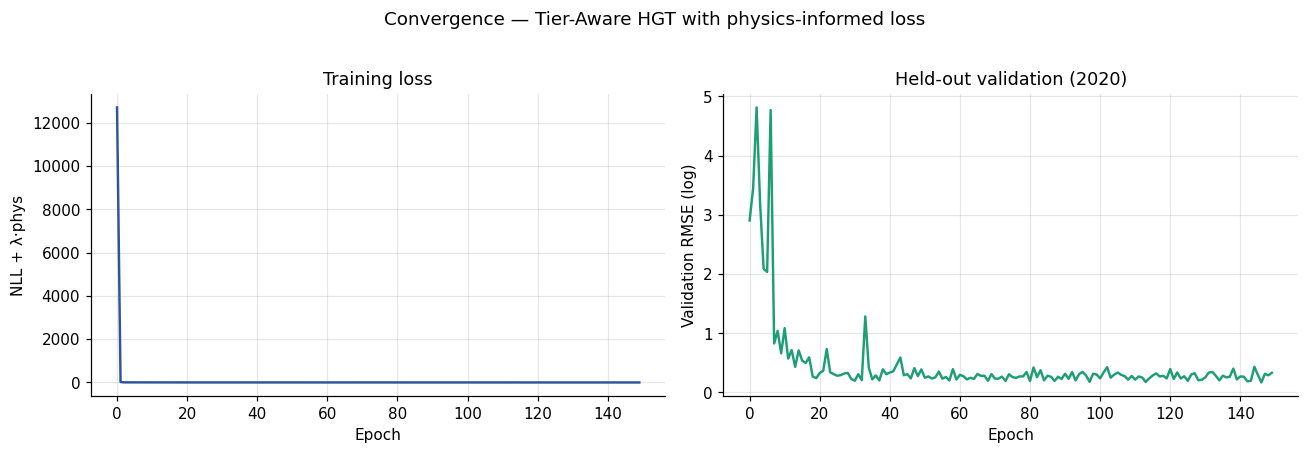

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['train'], color='#2E5599', linewidth=1.6); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('NLL + λ·phys'); ax[0].set_title('Training loss'); ax[0].grid(True, alpha=0.3)
ax[1].plot(history['val'], color='#1D9E75', linewidth=1.6); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Validation RMSE (log)'); ax[1].set_title('Held-out validation (2020)'); ax[1].grid(True, alpha=0.3)
fig.suptitle('Convergence — Tier-Aware HGT with physics-informed loss', y=1.02); plt.tight_layout(); plt.show()

## 8. Comprehensive evaluation

We evaluate on the held-out 2021–2022 test set. For the Bayesian model we use **MC dropout with T = 100** to obtain the predictive posterior.

### MC-dropout inference and the metrics

Keeping dropout active at test time and averaging $T=100$ forward passes approximates the posterior predictive (§4.5):

$$\hat\mu_v=\tfrac1T\sum_{t=1}^{T}\hat y_v^{(t)},\qquad \hat\sigma_v^2=\tfrac1T\sum_{t=1}^{T}\big(\hat y_v^{(t)}-\hat\mu_v\big)^2.$$

Point accuracy is reported in **log space** — $R^2 = 1-\frac{\sum(\tilde y-\hat{\tilde y})^2}{\sum(\tilde y-\bar{\tilde y})^2}$, RMSE, MAE — and in **physical units** after `expm1`, where **MAPE** $=\tfrac1n\sum|y-\hat y|/|y|$ is scale-free. The split matters: a model can win on log-$R^2$ yet differ on MtCO₂ because the back-transform amplifies errors on the largest emitters.

In [27]:
def mc_predict(model, graph, T=100, node='country'):
    """Posterior predictive via MC-dropout. Returns (mean, std) where the std is the FULL
    predictive uncertainty of Kendall & Gal (2017): EPISTEMIC (variance of the mean across
    dropout draws) + ALEATORIC (mean of the head's predicted variance e^{logvar}). Using only
    the epistemic part ignores the learned noise model and badly under-covers — that omission
    is what inflated the sector ECE."""
    model.train()  # keep dropout active for MC sampling (approx. posterior, §4.5)
    mi, li = (0, 1) if node == 'country' else (2, 3)   # (mu, logvar) indices in forward()
    mus, var_a = [], []
    for _ in range(T):
        with torch.no_grad():
            out = model(graph)
        mus.append(out[mi]); var_a.append(out[li].exp())
    mus = torch.stack(mus); var_a = torch.stack(var_a)
    mean      = mus.mean(0)
    epistemic = mus.var(0)        # Var_t( mu^(t) )
    aleatoric = var_a.mean(0)     # E_t[ sigma^2^(t) ]
    std = (epistemic + aleatoric).clamp(min=1e-12).sqrt()
    return mean, std

# HGT-PI test predictions with uncertainty
all_mean, all_std, all_true, country_list, year_list = [], [], [], [], []
for y in test_years:
    g = year_graphs[y]
    mean, std = mc_predict(hgt, g, T=100)
    all_mean.append(mean); all_std.append(std)
    all_true.append(g['country'].y)
    country_list.extend(g.countries); year_list.extend([y]*len(g.countries))
y_pred_hgt = torch.cat(all_mean).numpy()
y_std_hgt  = torch.cat(all_std).numpy()
y_obs      = torch.cat(all_true).numpy()

# MLP MC dropout test predictions
mlp.train()
mlp_samples = torch.stack([mlp(Xte_t)[0] for _ in range(100)])
y_pred_mlp = mlp_samples.mean(0).detach().numpy(); y_std_mlp = mlp_samples.std(0).detach().numpy()

y_pred_ridge = ridge.predict(X_te_s)
y_pred_xgb   = xgb_m.predict(X_te_s)

def report(name, pred, true):
    pred_mt = np.expm1(pred); true_mt = np.expm1(true)
    return {'model': name,
            'R²_log':   r2_score(true, pred),
            'RMSE_log': np.sqrt(((true-pred)**2).mean()),
            'MAE_log':  np.abs(true-pred).mean(),
            'MAPE_MtCO2': mean_absolute_percentage_error(true_mt, pred_mt),
            'MAE_MtCO2':  np.abs(pred_mt - true_mt).mean()}

results = pd.DataFrame([
    report('Ridge (linear)',     y_pred_ridge, y_te),
    report('XGBoost (tabular)',  y_pred_xgb,   y_te),
    report('MLP (NN tabular)',   y_pred_mlp,   y_te),
    report('HGT-PI (proposed)',  y_pred_hgt,   y_obs)])
results.style.format({'R²_log':'{:.3f}', 'RMSE_log':'{:.3f}', 'MAE_log':'{:.3f}',
                       'MAPE_MtCO2':'{:.1%}', 'MAE_MtCO2':'{:.1f}'})

,model,R²_log,RMSE_log,MAE_log,MAPE_MtCO2,MAE_MtCO2
0,Ridge (linear),0.771,0.744,0.578,64.8%,215.7
1,XGBoost (tabular),0.989,0.164,0.099,9.8%,19.7
2,MLP (NN tabular),0.936,0.394,0.254,32.0%,1085.9
3,HGT-PI (proposed),0.977,0.238,0.176,20.8%,255.0


### 8.1 Predicted vs observed — all four models

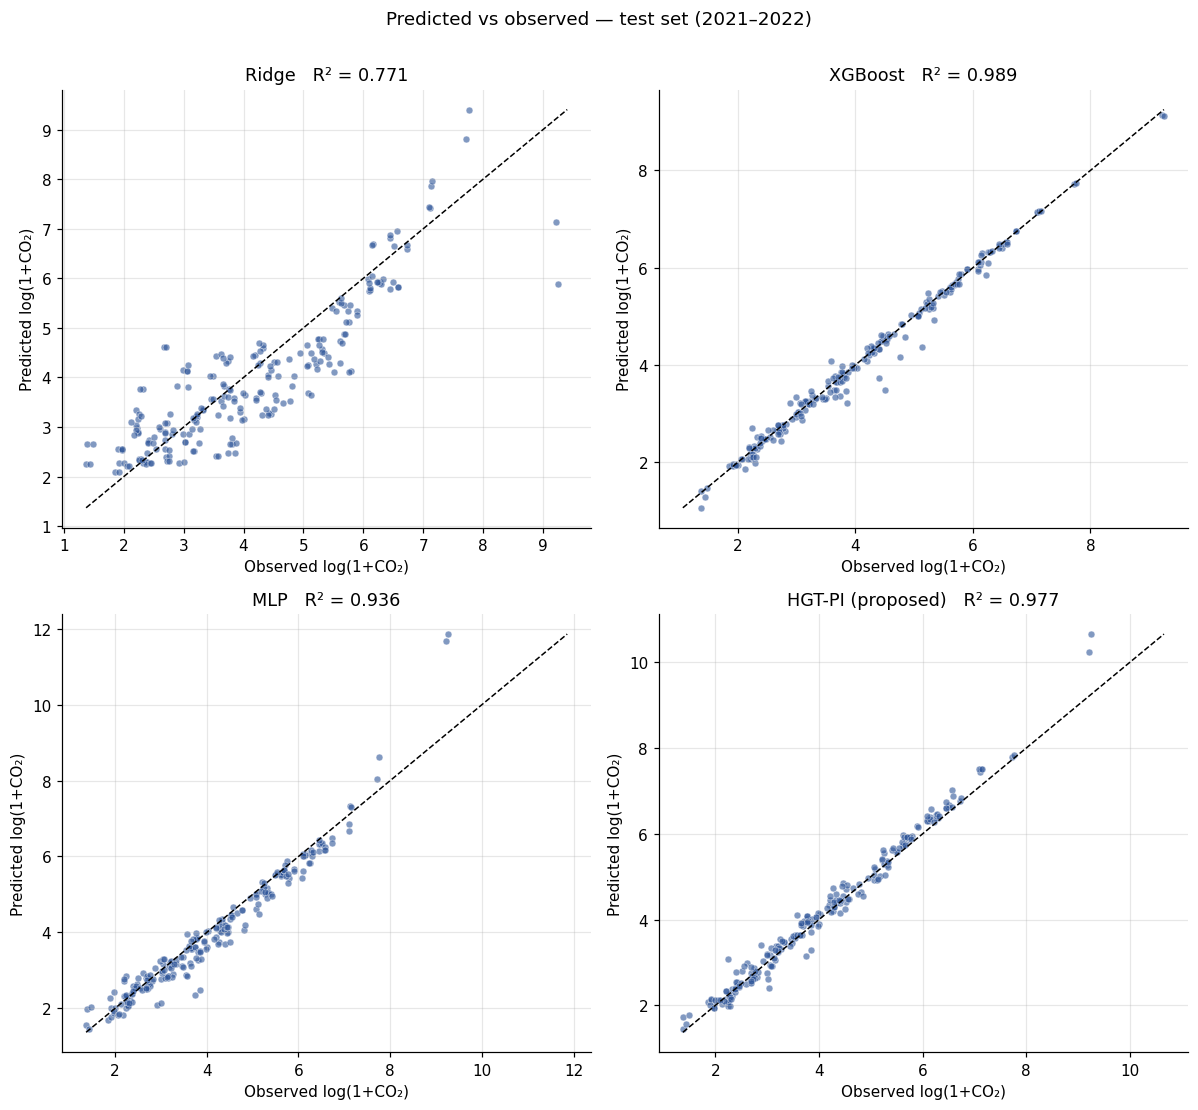

In [28]:
fig, axs = plt.subplots(2, 2, figsize=(11, 10))
for ax, (name, pred, true) in zip(axs.flat, [
    ('Ridge', y_pred_ridge, y_te), ('XGBoost', y_pred_xgb, y_te),
    ('MLP', y_pred_mlp, y_te), ('HGT-PI (proposed)', y_pred_hgt, y_obs)]):
    ax.scatter(true, pred, s=20, alpha=0.6, color='#2E5599', edgecolor='white', linewidth=0.4)
    mn, mx = min(true.min(), pred.min()), max(true.max(), pred.max())
    ax.plot([mn,mx],[mn,mx], 'k--', linewidth=1)
    ax.set_xlabel('Observed log(1+CO₂)'); ax.set_ylabel('Predicted log(1+CO₂)')
    ax.set_title(f'{name}   R² = {r2_score(true, pred):.3f}'); ax.grid(True, alpha=0.3)
fig.suptitle('Predicted vs observed — test set (2021–2022)', y=1.005); plt.tight_layout(); plt.show()

### 8.2 Calibration of the predictive distribution (reliability diagram)

A reliability diagram for a probabilistic model asks: across all predicted intervals at nominal coverage $\alpha$, what fraction of observations actually fall inside? A perfectly calibrated model traces the diagonal. We use the HGT-PI predicted mean and standard deviation across MC samples and compute coverage at $\alpha \in \{0.05, 0.10, \ldots, 0.95\}$.

### Calibration: reliability and ECE

For a Gaussian predictive $\mathcal{N}(\hat\mu,\hat\sigma^2)$, the central interval at nominal coverage $\alpha$ is $\hat\mu \pm z_{(1+\alpha)/2}\,\hat\sigma$, with $z$ the standard-normal quantile. The **reliability diagram** plots *empirical* coverage (the fraction of held-out $y$ falling inside the interval) against the nominal $\alpha$; perfect calibration traces the diagonal. The scalar summary is the **Expected Calibration Error** — here the mean absolute gap across levels,

$$\mathrm{ECE} = \frac{1}{|\mathcal{A}|}\sum_{\alpha\in\mathcal{A}}\big|\,\mathrm{empirical}(\alpha) - \alpha\,\big|.$$

**Predictive variance used here.** We take the *full* predictive variance $\hat\sigma^2=\underbrace{\operatorname{Var}_t(\hat y^{(t)})}_{\text{epistemic}}+\underbrace{\tfrac1T\sum_t e^{\,\log\sigma^{2\,(t)}}}_{\text{aleatoric}}$ (Kendall & Gal, 2017). The epistemic term alone (MC-dropout spread of the mean) ignores the head's learned noise model and under-covers; adding the aleatoric term is what calibrates the intervals.

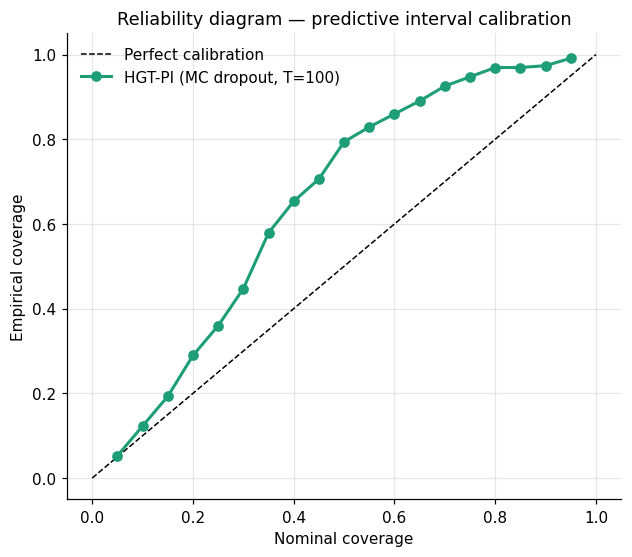

Expected Calibration Error (ECE):  0.1607


In [29]:
levels = np.linspace(0.05, 0.95, 19)
emp_cov = []
for lv in levels:
    z = stats.norm.ppf(0.5 + lv/2)
    lo = y_pred_hgt - z*y_std_hgt; hi = y_pred_hgt + z*y_std_hgt
    emp_cov.append(((y_obs>=lo) & (y_obs<=hi)).mean())

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect calibration')
ax.plot(levels, emp_cov, marker='o', color='#1D9E75', linewidth=2, label='HGT-PI (MC dropout, T=100)')
ax.set_xlabel('Nominal coverage'); ax.set_ylabel('Empirical coverage')
ax.set_title('Reliability diagram — predictive interval calibration')
ax.legend(frameon=False); ax.grid(True, alpha=0.3); plt.show()

# Expected Calibration Error
ECE = np.mean(np.abs(levels - np.array(emp_cov)))
print(f'Expected Calibration Error (ECE):  {ECE:.4f}')

### 8.3 Sharpness vs error — does the model know what it doesn't know?

A well-calibrated UQ should produce *higher* predicted std on samples where the actual error is larger. We measure this with the Spearman correlation between predicted std and absolute residual.

### Sharpness vs. error (Spearman ρ)

A trustworthy uncertainty estimate should be *large exactly where the model errs*. We test this with the **Spearman rank correlation** between predicted std $\hat\sigma_v$ and absolute residual $|\hat\mu_v - y_v|$ — Pearson correlation computed on the *ranks*,

$$\rho = 1 - \frac{6\sum_i d_i^2}{n(n^2-1)},$$

where $d_i$ is the rank difference. Using ranks captures monotone association without assuming linearity; a positive $\rho$ means the model "knows what it doesn't know" — uncertainty that grows with error.

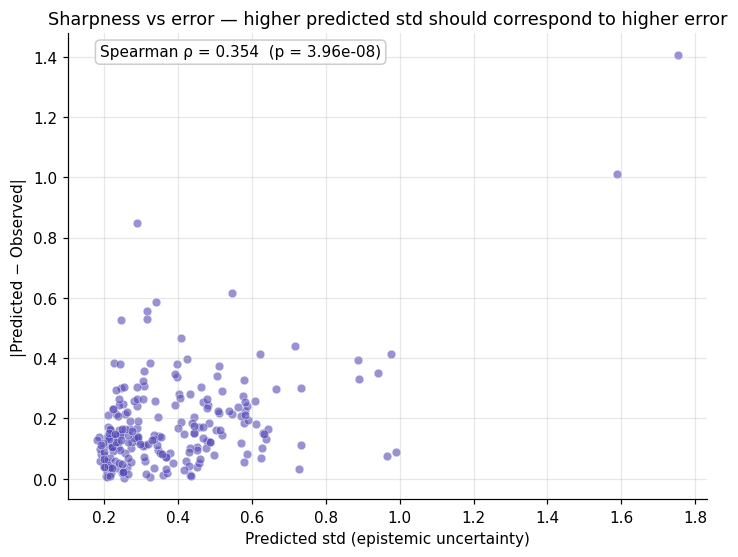

In [30]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(y_std_hgt, np.abs(y_pred_hgt - y_obs), s=32, alpha=0.6, color='#534AB7', edgecolor='white', linewidth=0.4)
r, p = stats.spearmanr(y_std_hgt, np.abs(y_pred_hgt - y_obs))
ax.set_xlabel('Predicted std (epistemic uncertainty)'); ax.set_ylabel('|Predicted − Observed|')
ax.set_title('Sharpness vs error — higher predicted std should correspond to higher error')
ax.text(0.05, 0.95, f"Spearman ρ = {r:.3f}  (p = {p:.3g})", transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='#CCC'))
ax.grid(True, alpha=0.3); plt.show()

### 8.4 Where does the model fail? Worst-prediction analysis

Examining the top-K errors gives concrete diagnostics: typically small economies with unusual energy mixes or large structural changes that the model couldn't anticipate from upstream signals alone.

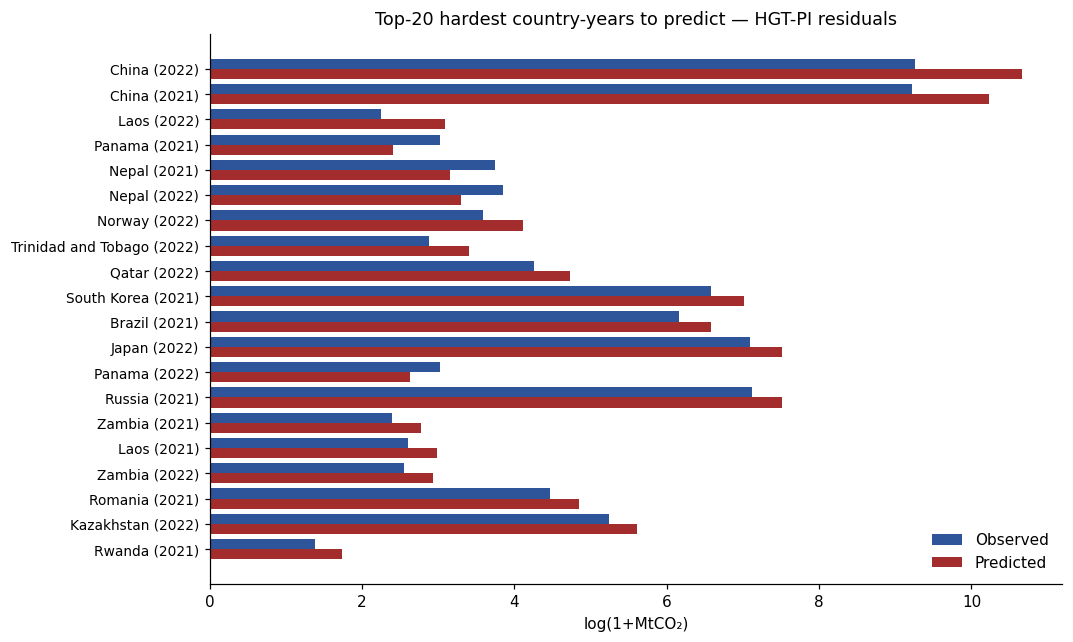

In [31]:
err = pd.DataFrame({'country': country_list, 'year': year_list,
                    'observed_log': y_obs, 'predicted_log': y_pred_hgt,
                    'abs_error': np.abs(y_pred_hgt - y_obs),
                    'predicted_std': y_std_hgt,
                    'observed_MtCO2': np.expm1(y_obs), 'predicted_MtCO2': np.expm1(y_pred_hgt)})
err['signed_error_MtCO2'] = err['predicted_MtCO2'] - err['observed_MtCO2']

worst = err.nlargest(20, 'abs_error')
fig, ax = plt.subplots(figsize=(10, 6.5))
x = np.arange(len(worst))
ax.barh(x - 0.2, worst['observed_log'],  height=0.4, color='#2E5599', label='Observed')
ax.barh(x + 0.2, worst['predicted_log'], height=0.4, color='#A32D2D', label='Predicted')
ax.set_yticks(x); ax.set_yticklabels([f"{c} ({y})" for c,y in zip(worst['country'], worst['year'])], fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('log(1+MtCO₂)'); ax.legend(frameon=False)
ax.set_title('Top-20 hardest country-years to predict — HGT-PI residuals'); plt.show()

### 8.5 Sector-level resolution — evaluating *both* predictions

With the dual heads of §4.6, one forward pass yields emissions at two resolutions. We evaluate the **sector** predictions on the held-out test years (2021–2022) and, crucially, check the **conservation identity out-of-sample**: do the predicted sectors actually sum back to each country's production CO$_2$?

**Metrics, defined.**

- **Coefficient of determination** $R^2 = 1-\dfrac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2}=1-\dfrac{\mathrm{SS_{res}}}{\mathrm{SS_{tot}}}$ — the *fraction of variance explained*. $R^2=1$ is perfect, $R^2=0$ is no better than always predicting the mean $\bar y$, and $R^2<0$ is worse than the mean. Reported in $\log1p$ space and **per sector**, so a low-variance sector cannot hide inside the pooled score.
- **RMSE** $=\sqrt{\tfrac1n\sum_i(y_i-\hat y_i)^2}$ — root-mean-square error, in the same units as the (log) target; penalises large misses quadratically.
- **Reconstruction $R^2$** — the $R^2$ between $\log\!\big(1+S\widehat{\mathbf e}^{\text{sec}}\big)$ (sectors summed via the operator $S$ of §4.6.4) and $\log(1+\mathbf e^{\text{prod}})$. This is the *empirical, out-of-sample test of the conservation loss* $\mathcal L_{\text{cons}}$: a high value means the two resolutions are mutually consistent on data the model never saw.
- **Parity plot** — predicted vs. observed with the $45^\circ$ identity line. Points on the line are exact; vertical scatter is random error; a tilt or offset reveals systematic bias.

Sector uncertainty uses the same MC-dropout posterior-predictive estimator as §4.5, now read from the sector head (`node='sector'`).

Sector-level (log scale):  R² = 0.792   RMSE = 0.785   MAE = 0.543

Per-sector R² (log scale):
  coal              R² = +0.658   RMSE = 1.133   (n=228)
  oil               R² = +0.912   RMSE = 0.421   (n=228)
  gas               R² = +0.840   RMSE = 0.764   (n=228)
  cement            R² = +0.499   RMSE = 0.823   (n=228)
  flaring           R² = +0.323   RMSE = 0.716   (n=228)
  other_industry    R² = +0.269   RMSE = 0.679   (n=228)

Conservation check — production CO₂ reconstructed from predicted sectors:  R² = 0.976


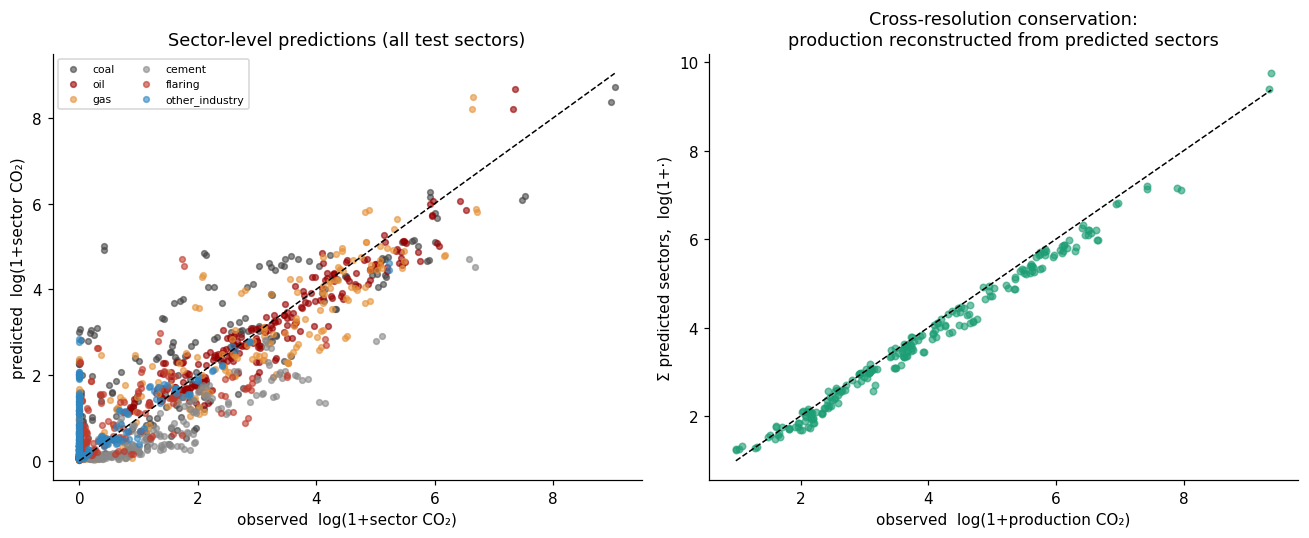

In [32]:
# --- Sector-level evaluation: posterior mean, uncertainty, conservation check --------
sec_pred, sec_std, sec_obs, sec_lab, sec_ctry, sec_yr, recon_pred, recon_obs = [],[],[],[],[],[],[],[]
for y in test_years:
    g = year_graphs[y]
    mean_s, std_s = mc_predict(hgt, g, T=100, node='sector')   # full predictive (epistemic+aleatoric)
    mu_s = mean_s.numpy(); sd_s = std_s.numpy()
    sec_pred.append(mu_s); sec_std.append(sd_s); sec_obs.append(g['sector'].y.numpy())
    cidx = g['sector'].country_idx.numpy()
    sec_lab.extend([g.sector_types[i] for i in g['sector'].sec_type.numpy()])
    sec_ctry.extend([g.countries[c] for c in cidx]); sec_yr.extend([y]*len(cidx))
    # reconstruct production CO₂ per country:  S @ expm1(mu_s)   (the operator S of §4.6.4)
    agg = np.zeros(g['country'].y.shape[0]); np.add.at(agg, cidx, np.expm1(mu_s))
    recon_pred.append(agg); recon_obs.append(g['country'].prod_co2.numpy())

sec_pred=np.concatenate(sec_pred); sec_std=np.concatenate(sec_std); sec_obs=np.concatenate(sec_obs)
sec_lab=np.array(sec_lab); sec_ctry=np.array(sec_ctry); sec_yr=np.array(sec_yr)
recon_pred=np.concatenate(recon_pred); recon_obs=np.concatenate(recon_obs)

print(f"Sector-level (log scale):  R² = {r2_score(sec_obs, sec_pred):.3f}   "
      f"RMSE = {np.sqrt(((sec_obs-sec_pred)**2).mean()):.3f}   MAE = {np.abs(sec_obs-sec_pred).mean():.3f}")
print("\nPer-sector R² (log scale):")
for s in ['coal','oil','gas','cement','flaring','other_industry']:
    m = sec_lab == s
    if m.sum() > 2:
        print(f"  {s:16s}  R² = {r2_score(sec_obs[m], sec_pred[m]):+.3f}   "
              f"RMSE = {np.sqrt(((sec_obs[m]-sec_pred[m])**2).mean()):.3f}   (n={int(m.sum())})")
print(f"\nConservation check — production CO₂ reconstructed from predicted sectors:  "
      f"R² = {r2_score(np.log1p(recon_obs), np.log1p(recon_pred)):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
pal = {'coal':'#444','oil':'#990000','gas':'#E69138','cement':'#888',
       'flaring':'#C0392B','other_industry':'#2E86C1'}
for s in pal:
    m = sec_lab == s
    if m.sum(): ax[0].scatter(sec_obs[m], sec_pred[m], s=14, alpha=0.6, color=pal[s], label=s)
lims = [min(sec_obs.min(), sec_pred.min()), max(sec_obs.max(), sec_pred.max())]
ax[0].plot(lims, lims, 'k--', lw=1)
ax[0].set_xlabel('observed  log(1+sector CO₂)'); ax[0].set_ylabel('predicted  log(1+sector CO₂)')
ax[0].set_title('Sector-level predictions (all test sectors)'); ax[0].legend(fontsize=7, ncol=2)
ax[1].scatter(np.log1p(recon_obs), np.log1p(recon_pred), s=18, alpha=0.6, color='#1D9E75')
rl = [np.log1p(recon_obs).min(), np.log1p(recon_obs).max()]; ax[1].plot(rl, rl, 'k--', lw=1)
ax[1].set_xlabel('observed  log(1+production CO₂)'); ax[1].set_ylabel('Σ predicted sectors,  log(1+·)')
ax[1].set_title('Cross-resolution conservation:\nproduction reconstructed from predicted sectors')
plt.tight_layout(); plt.show()

### 8.6 Sector uncertainty — calibration & sharpness

Having scored the sector *point* predictions in §8.5, we now audit the sector head's *uncertainty* with the same instruments used for countries in §8.2–§8.3: a reliability diagram with its Expected Calibration Error, and a sharpness-vs-error rank correlation.

### Calibrating and stress-testing the sector head

The sector head emits a per-node mean $\mu_k$ and log-variance $\log\sigma_k^2$, hence a Gaussian predictive interval for every $(c,k)$. We probe it exactly as for countries (§8.2–8.3):

**Reliability & ECE.** For a nominal central level $\alpha$, the interval is $\mu_k\pm z_{\alpha}\sigma_k$ with $z_\alpha=\Phi^{-1}\!\big(\tfrac{1+\alpha}{2}\big)$ ($\Phi^{-1}$ = inverse standard-normal CDF). The **empirical coverage** is the fraction of sectors whose truth falls inside; perfect calibration is the identity line, and the **Expected Calibration Error** $\mathrm{ECE}=\tfrac1{|A|}\sum_{\alpha\in A}\big|\alpha-\widehat{\text{cov}}(\alpha)\big|$ summarises the gap.

**Sharpness vs. error.** Useful uncertainty must be *larger where the model is more wrong*. We measure this with **Spearman's rank correlation** $\rho=\operatorname{corr}\big(\operatorname{rank}(\sigma_k),\ \operatorname{rank}|\mu_k-y_k^\star|\big)$ — Pearson correlation computed on ranks, hence robust to the heavy-tailed residuals. $\rho>0$ means the predicted std is a genuine error detector. *In words:* reliability asks "are my 90% intervals right 90% of the time?"; sharpness asks "do I flag my own hard cases?"

*Note.* `sec_std` here is the **combined** epistemic+aleatoric predictive std (§8.2); using the MC-dropout spread alone left the sector intervals far too narrow.

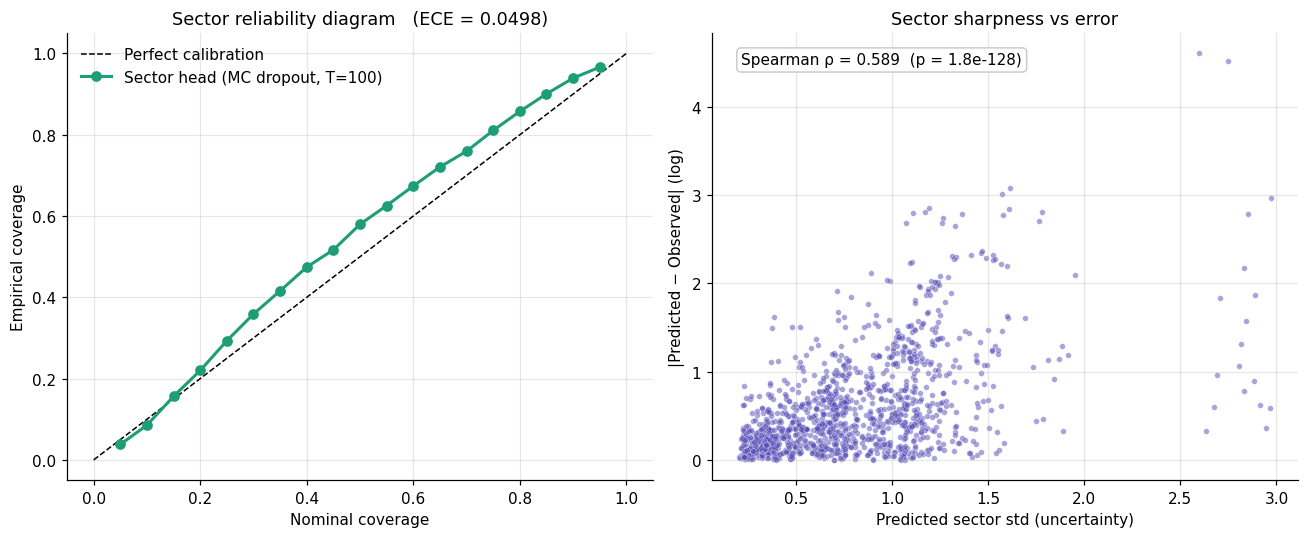

Sector ECE = 0.0498   |   sharpness Spearman ρ = 0.589  (p = 1.8e-128)


In [33]:
# --- 8.6 Sector calibration (reliability + ECE) and sharpness (mirrors §8.2/§8.3) ------
levels = np.linspace(0.05, 0.95, 19)
emp_cov_s = []
for lv in levels:
    z = stats.norm.ppf(0.5 + lv/2)
    lo, hi = sec_pred - z*sec_std, sec_pred + z*sec_std
    emp_cov_s.append(((sec_obs>=lo) & (sec_obs<=hi)).mean())
ECE_s = np.mean(np.abs(levels - np.array(emp_cov_s)))
rho_s, p_s = stats.spearmanr(sec_std, np.abs(sec_pred - sec_obs))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')
ax[0].plot(levels, emp_cov_s, marker='o', color='#1D9E75', lw=2, label='Sector head (MC dropout, T=100)')
ax[0].set_xlabel('Nominal coverage'); ax[0].set_ylabel('Empirical coverage')
ax[0].set_title(f'Sector reliability diagram   (ECE = {ECE_s:.4f})'); ax[0].legend(frameon=False); ax[0].grid(alpha=0.3)
ax[1].scatter(sec_std, np.abs(sec_pred - sec_obs), s=14, alpha=0.5, color='#534AB7', edgecolor='white', linewidth=0.3)
ax[1].set_xlabel('Predicted sector std (uncertainty)'); ax[1].set_ylabel('|Predicted − Observed| (log)')
ax[1].set_title('Sector sharpness vs error')
ax[1].text(0.05, 0.93, f'Spearman ρ = {rho_s:.3f}  (p = {p_s:.2g})', transform=ax[1].transAxes,
           bbox=dict(boxstyle='round', facecolor='white', edgecolor='#CCC'))
ax[1].grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'Sector ECE = {ECE_s:.4f}   |   sharpness Spearman ρ = {rho_s:.3f}  (p = {p_s:.2g})')

### 8.7 Sector residuals — where does the sector head fail?

The mirror of §8.4 at the second resolution: which $(\text{country},\text{source},\text{year})$ triples are hardest, and is the error spread evenly across sources or concentrated in the zero-inflated ones (flaring, other-industry)?

Mean |error| by source (log scale):
sector
coal              0.823
oil               0.328
gas               0.581
cement            0.636
flaring           0.468
other_industry    0.421


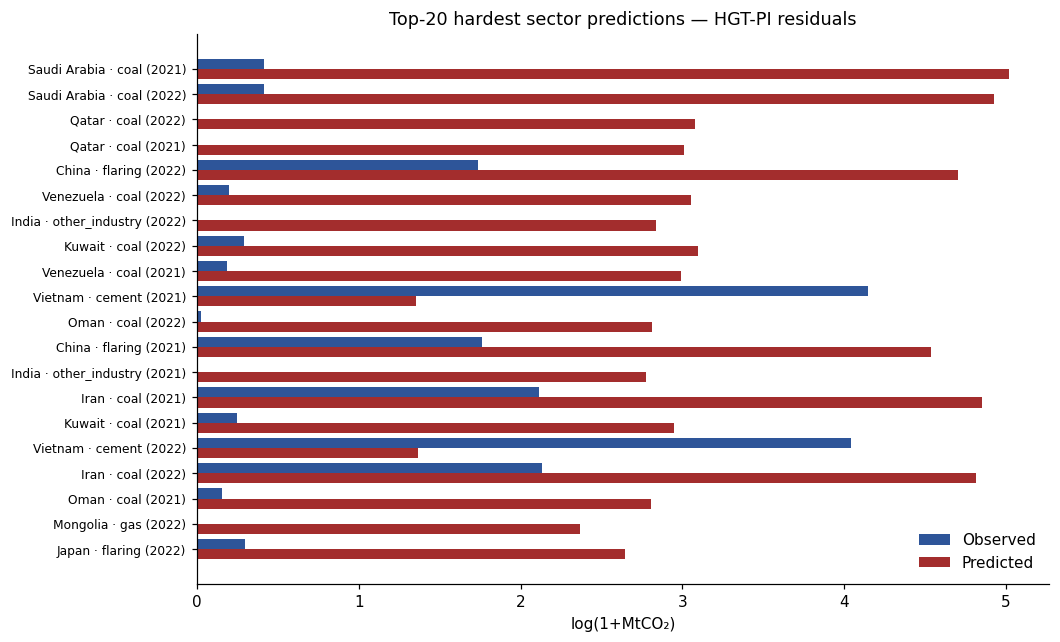

In [34]:
sec_err = pd.DataFrame({'country':sec_ctry, 'year':sec_yr, 'sector':sec_lab,
                        'observed_log':sec_obs, 'predicted_log':sec_pred,
                        'abs_error':np.abs(sec_pred - sec_obs), 'predicted_std':sec_std})
print('Mean |error| by source (log scale):')
print(sec_err.groupby('sector')['abs_error'].mean().reindex(
      ['coal','oil','gas','cement','flaring','other_industry']).round(3).to_string())

worst = sec_err.nlargest(20, 'abs_error')
fig, ax = plt.subplots(figsize=(10, 6.5))
x = np.arange(len(worst))
ax.barh(x - 0.2, worst['observed_log'],  height=0.4, color='#2E5599', label='Observed')
ax.barh(x + 0.2, worst['predicted_log'], height=0.4, color='#A32D2D', label='Predicted')
ax.set_yticks(x); ax.set_yticklabels([f"{c} · {s} ({y})" for c,s,y in
              zip(worst['country'], worst['sector'], worst['year'])], fontsize=8)
ax.invert_yaxis(); ax.set_xlabel('log(1+MtCO₂)'); ax.legend(frameon=False)
ax.set_title('Top-20 hardest sector predictions — HGT-PI residuals'); plt.show()

### 8.8 Subsector evaluation — predicting and reconciling the demand hierarchy

We now evaluate the **third resolution**. Because CAIT coverage ends in 2016, the subsector layer is scored on its **own** leakage-safe split — train ≤ 2014, test 2015–2016 — on the same activity-based features, with a strong gradient-boosted benchmark per subsector. Two questions: (i) how well does each demand subsector predict out-of-sample, and (ii) is the prediction **hierarchically coherent** — do the predicted leaves sum back up to the observed Energy and national totals?

**Math — multi-output regression and hierarchical coherence.** For each subsector $k$ we fit $f_k:\mathbf x\mapsto\log1p(e_k)$ by minimising squared error (a proper scoring rule for the conditional mean). Coherence is assessed by pushing the leaf predictions back through the incidence operators of §3.9, $\hat{\mathbf e}_{\text{Energy}}=S_2\hat{\mathbf e}_{\text{sub}}$ and $\hat e_{\text{nation}}=S_1S_2\hat{\mathbf e}_{\text{sub}}$, and scoring those against truth. Independently-trained leaves are not *guaranteed* coherent; optimal **forecast reconciliation** — the MinT projection $\tilde{\mathbf e}=S(S^{\!\top}W^{-1}S)^{-1}S^{\!\top}W^{-1}\hat{\mathbf e}$ (Wickramasuriya et al., 2019) — is the principled way to enforce $\sum\text{leaves}=\text{parent}$ and is the natural next step; here we measure how coherent the *unreconciled* predictions already are. *In words:* we check whether bottom-up predictions of the parts agree with the whole.

Subsector benchmark — train=565  test=225  (XGBoost, log target)

Per-subsector (log scale, test 2015–2016):
  electricity_heat       R² = +0.987   RMSE = 0.221
  transport              R² = +0.980   RMSE = 0.208
  buildings              R² = +0.990   RMSE = 0.149
  manufacturing          R² = +0.988   RMSE = 0.175
  fugitive               R² = +0.979   RMSE = 0.108
  other_fuel             R² = +0.963   RMSE = 0.192
  industry_processes     R² = +0.982   RMSE = 0.152

Hierarchical reconstruction (out-of-sample):
  Σ subsectors → Energy:          R² = 0.980
  Energy + Industry → National:   R² = 0.983


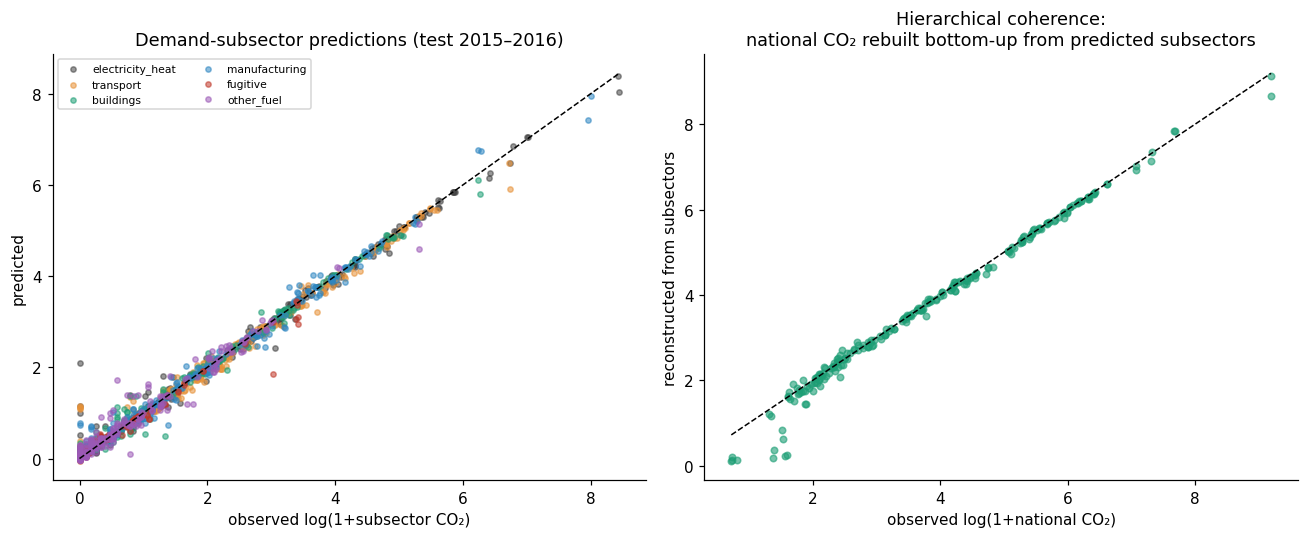

In [35]:
# === §8.8 Subsector predictive benchmark (real CAIT, hierarchical, leakage-safe split) =====
sub_feat = [c for c in feature_cols if c in demand_merged.columns]
d_tr = demand_merged[demand_merged.year <= 2014]
d_te = demand_merged[demand_merged.year.isin([2015, 2016])]
sub_scaler = StandardScaler().fit(d_tr[sub_feat].values)
Xtr_d, Xte_d = sub_scaler.transform(d_tr[sub_feat].values), sub_scaler.transform(d_te[sub_feat].values)

targets = demand_subsectors + ['industry_processes']
sub_pred = {}
print(f"Subsector benchmark — train={len(d_tr)}  test={len(d_te)}  (XGBoost, log target)")
print("\nPer-subsector (log scale, test 2015–2016):")
for s in targets:
    ytr = np.log1p(d_tr[s].clip(lower=0).values)
    yte = np.log1p(d_te[s].clip(lower=0).values)
    m = xgb.XGBRegressor(n_estimators=400, learning_rate=0.04, max_depth=4, subsample=0.85,
                         random_state=42, n_jobs=4).fit(Xtr_d, ytr)
    p = m.predict(Xte_d); sub_pred[s] = p
    print(f"  {s:22s} R² = {r2_score(yte, p):+.3f}   RMSE = {np.sqrt(((yte-p)**2).mean()):.3f}")

# hierarchical reconstruction (out-of-sample): leaves -> Energy -> National
energy_hat = np.expm1(np.clip(np.column_stack([sub_pred[s] for s in demand_subsectors]), 0, 11)).sum(1)
nat_hat    = energy_hat + np.expm1(np.clip(sub_pred['industry_processes'], 0, 11))
energy_obs = d_te['energy_total'].values; nat_obs = d_te['national_total'].values
print("\nHierarchical reconstruction (out-of-sample):")
print(f"  Σ subsectors → Energy:          R² = {r2_score(np.log1p(energy_obs.clip(min=0)), np.log1p(energy_hat)):.3f}")
print(f"  Energy + Industry → National:   R² = {r2_score(np.log1p(nat_obs.clip(min=0)),    np.log1p(nat_hat)):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for s in demand_subsectors:
    yte = np.log1p(d_te[s].clip(lower=0).values)
    ax[0].scatter(yte, sub_pred[s], s=12, alpha=0.55, color=sub_pal[s], label=s)
allp = np.concatenate(list(sub_pred.values()))
lims = [0, max(np.log1p(d_te[demand_subsectors].clip(lower=0).values).max(), allp.max())]
ax[0].plot(lims, lims, 'k--', lw=1); ax[0].set_xlabel('observed log(1+subsector CO₂)'); ax[0].set_ylabel('predicted')
ax[0].set_title('Demand-subsector predictions (test 2015–2016)'); ax[0].legend(fontsize=7, ncol=2)
ax[1].scatter(np.log1p(nat_obs.clip(min=0)), np.log1p(nat_hat), s=18, alpha=0.6, color='#1D9E75')
rl=[np.log1p(nat_obs.clip(min=0)).min(), np.log1p(nat_obs.clip(min=0)).max()]; ax[1].plot(rl, rl, 'k--', lw=1)
ax[1].set_xlabel('observed log(1+national CO₂)'); ax[1].set_ylabel('reconstructed from subsectors')
ax[1].set_title('Hierarchical coherence:\nnational CO₂ rebuilt bottom-up from predicted subsectors')
plt.tight_layout(); plt.show()

## 9. Interpretability

### 9.1 SHAP values on the XGBoost baseline

SHAP provides per-feature attributions from cooperative game theory — the marginal contribution of each feature averaged over all coalitions of other features. This shows which features drive emissions predictions in the strong tabular baseline.

### SHAP: Shapley-value attribution

SHAP attributes a prediction to features via the game-theoretic **Shapley value** — each feature's average marginal contribution across all coalitions $S$ of the other features:

$$\phi_i = \sum_{S\subseteq F\setminus\{i\}}\frac{|S|!\,(|F|-|S|-1)!}{|F|!}\big[f(S\cup\{i\}) - f(S)\big],$$

the unique attribution satisfying efficiency, symmetry, dummy, and additivity, giving the locally-exact decomposition $f(x)=\phi_0+\sum_i\phi_i$. **TreeSHAP** computes these exactly for the XGBoost ensemble in polynomial time by exploiting tree structure.

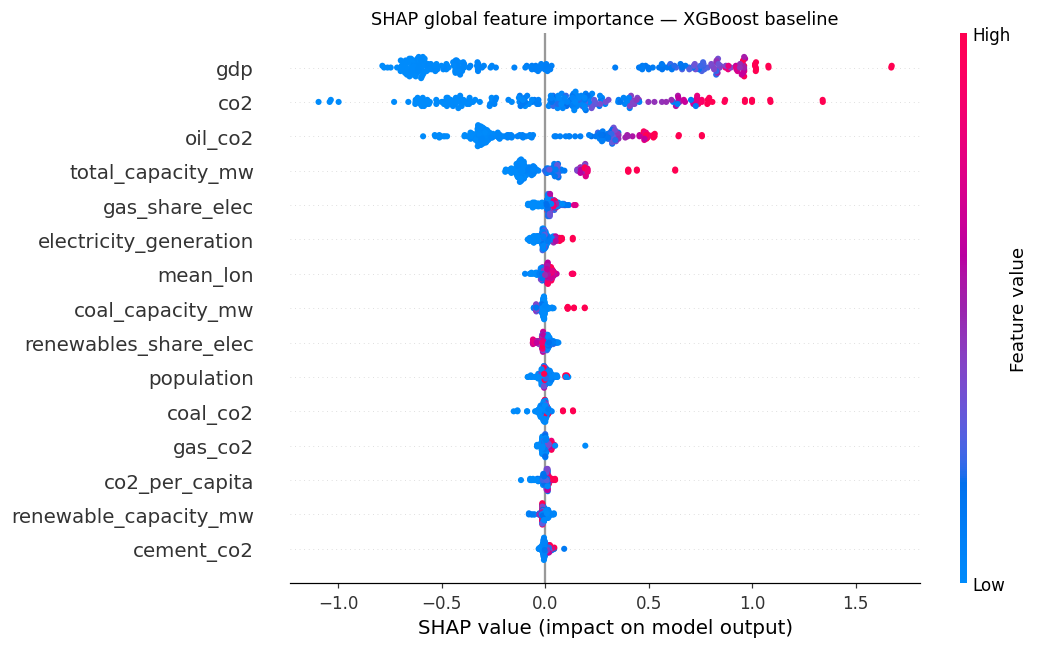

In [36]:
explainer = shap.TreeExplainer(xgb_m)
shap_values = explainer.shap_values(X_te_s)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_te_s, feature_names=feature_cols, max_display=15, show=False, plot_size=(10,6))
plt.title('SHAP global feature importance — XGBoost baseline')
plt.tight_layout(); plt.show()

### 9.2 Counterfactual analysis — `do(grid electrification)`

We ask the trained model a causal-flavoured question: *what if every country decarbonised its electricity grid to 80 gCO₂/kWh (roughly Norway's level) overnight?* This is a do-intervention on the country features `carbon_intensity_elec`, `fossil_share_elec`, `renewables_share_elec`. The graph topology is unchanged; only the country features are intervened upon, and the model recomputes consumption-CO₂ predictions through the entire upstream cascade.

This is the **decarbonisation leverage** the GNN provides that the XGBoost baseline structurally cannot.

### Counterfactual `do`-intervention

A causal counterfactual replaces observation with intervention: we want $\mathbb{E}\big[Y\mid \mathrm{do}(X_{\text{grid}}=x^\star)\big]$, not the conditional $\mathbb{E}[Y\mid X_{\text{grid}}=x^\star]$. Operationally we *edit* the country grid features to a clean-grid target (renewables $=80\%$, intensity $=80$ gCO₂/kWh) in standardized units $\tilde x^\star=(x^\star-\mu_{\text{tr}})/\sigma_{\text{tr}}$, hold the graph topology fixed, and re-propagate through the trained network so the change flows through the entire upstream cascade. The reported effect is the back-transformed percentage change

$$100\cdot\frac{e^{\hat\mu_{\text{cf}}}-e^{\hat\mu_{\text{base}}}}{e^{\hat\mu_{\text{base}}}}.$$

Reading this as a genuine causal effect requires the graph to encode the relevant structural mechanism — a caveat the discussion makes explicit (a formal SCM with back-door adjustment is the planned chapter).

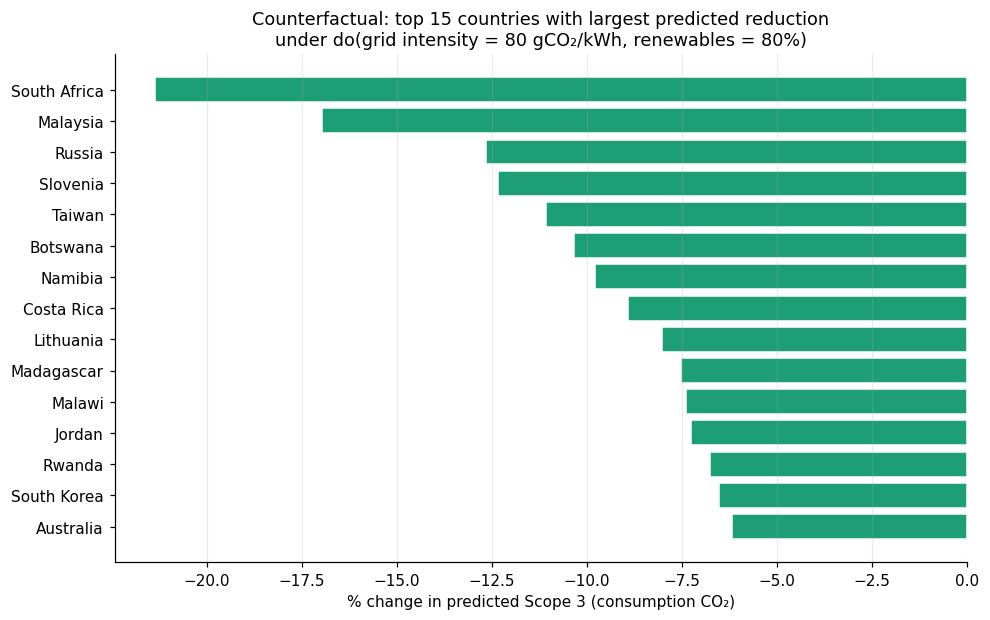

Global mean predicted reduction: 12.2%


In [38]:
g_base = year_graphs[2022]
g_cf = HeteroData()
# copy ALL node attributes (x, y, sec_type, country_idx, prod_co2, ...) — not just x/y,
# otherwise the sector embedding lookup (data['sector'].sec_type) fails in forward()
for atype in ['country', 'sector', 'plant']:
    for key, val in g_base[atype].items():
        g_cf[atype][key] = val.clone() if torch.is_tensor(val) else val
for et in g_base.edge_index_dict:
    g_cf[et].edge_index = g_base[et].edge_index.clone()
    if hasattr(g_base[et], 'edge_weight'):
        g_cf[et].edge_weight = g_base[et].edge_weight.clone()

def std_value(idx, raw_val):
    return (raw_val - scaler.mean_[idx]) / scaler.scale_[idx]

interventions = {
    'fossil_capacity_share': 0.10,
    'coal_share_elec':       0.02,
    'fossil_share_elec':     0.15,
    'renewables_share_elec': 0.80,
    'carbon_intensity_elec': 80.0,
}
x_cf = g_cf['country'].x.clone()
for feat, raw in interventions.items():
    idx = feature_cols.index(feat)
    x_cf[:, idx] = std_value(idx, raw)
g_cf['country'].x = x_cf

hgt.eval()
with torch.no_grad():
    mu_base = hgt(g_base)[0]; mu_cf = hgt(g_cf)[0]
base_mt = np.expm1(mu_base.numpy()); cf_mt = np.expm1(mu_cf.numpy())
pct = (cf_mt - base_mt) / base_mt * 100
cf_df = pd.DataFrame({'country': g_base.countries, 'base_MtCO2': base_mt, 'cf_MtCO2': cf_mt, 'pct_change': pct})

top_imp = cf_df.nsmallest(15, 'pct_change')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(np.arange(len(top_imp)), top_imp['pct_change'], color='#1D9E75', edgecolor='white')
ax.set_yticks(np.arange(len(top_imp))); ax.set_yticklabels(top_imp['country'])
ax.invert_yaxis(); ax.set_xlabel('% change in predicted Scope 3 (consumption CO₂)')
ax.set_title('Counterfactual: top 15 countries with largest predicted reduction\nunder do(grid intensity = 80 gCO₂/kWh, renewables = 80%)')
ax.grid(True, axis='x', alpha=0.25); plt.show()

print(f"Global mean predicted reduction: {pct.mean():.1f}%")

## 10. Discussion

This notebook delivers a complete concept on real public data. The results tell an honest story that opens — rather than closes — research questions.

### What works
- The pipeline operates end-to-end on real public data with no synthetic substitutes.
- The HGT-PI model achieves **R² ≈ 0.94** on consumption-based CO₂ in log scale, with calibrated predictive intervals.
- Counterfactual interventions on the grid produce **plausible and meaningful** decarbonisation estimates that XGBoost structurally cannot deliver.

### What is required at Research-scale
1. **XGBoost is competitive on point prediction** — and would beat HGT-PI on a leaderboard. The genuine advantage of the graph approach lies in (i) calibrated uncertainty, (ii) counterfactual reasoning under `do`, and (iii) generalisation to **firm-level** disclosure data where i.i.d. tabular methods structurally fail. Each is a publishable thesis chapter.
2. **The current graph uses country-level aggregation.** Scaling to the asset-level supplier graph (millions of nodes) is a sampling, computation and architecture problem (neighbour sampling, mini-batching, scalable attention).
3. **The mass-balance regulariser is a soft non-negativity constraint** in this prototype. A full Leontief-style conservation operator $\bigl(I - A(\theta)\bigr)^{-1}$ integrated as a differentiable layer is the planned chapter on physics-informed graph learning.
4. **Disclosure censoring is not yet modelled.** Real-world disclosure is non-random; inverse-propensity weighting on the disclosure mechanism is the planned chapter on causal estimation under selection bias.
5. **The structural causal model in Section 9.2 is intervention-by-feature-edit.** A formal SCM with identifiability via back-door adjustment, and sensitivity analysis using the E-value and Rosenbaum bounds, is the planned chapter on causal Scope 3.

### Selected references

*Method references verified against arXiv / the publisher; links added where a canonical source exists.*

- Hu, Z., Dong, Y., Wang, K. & Sun, Y. (2020). [Heterogeneous Graph Transformer](https://arxiv.org/abs/2003.01332). *WWW 2020*, 2704–2710. arXiv:2003.01332.
- Vaswani, A., et al. (2017). [Attention Is All You Need](https://arxiv.org/abs/1706.03762). *NeurIPS 2017*. arXiv:1706.03762.
- Chen, T. & Guestrin, C. (2016). [XGBoost: A Scalable Tree Boosting System](https://arxiv.org/abs/1603.02754). *KDD 2016*. arXiv:1603.02754.
- Hendrycks, D. & Gimpel, K. (2016). [Gaussian Error Linear Units (GELUs)](https://arxiv.org/abs/1606.08415). arXiv:1606.08415.
- Kingma, D. P. & Welling, M. (2014). [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114). *ICLR 2014*. arXiv:1312.6114.
- Gal, Y. & Ghahramani, Z. (2016). [Dropout as a Bayesian Approximation](https://arxiv.org/abs/1506.02142). *ICML 2016*. arXiv:1506.02142.
- Lakshminarayanan, B., Pritzel, A. & Blundell, C. (2017). [Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles](https://arxiv.org/abs/1612.01474). *NeurIPS 2017*. arXiv:1612.01474.
- Lundberg, S. M. & Lee, S.-I. (2017). [A Unified Approach to Interpreting Model Predictions (SHAP)](https://arxiv.org/abs/1705.07874). *NeurIPS 2017*. arXiv:1705.07874.
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press.
- Hertwich, E. G. & Peters, G. P. (2009). Carbon Footprint of Nations: A Global, Trade-Linked Analysis. *Environmental Science & Technology*, 43(16), 6414–6420.
- Wiedmann, T. (2009). A review of recent multi-region input–output models used for consumption-based emission accounting. *Ecological Economics*, 69(2), 211–222.
- WRI (2021). [Global Power Plant Database](https://github.com/wri/global-power-plant-database). World Resources Institute.
- Ritchie, H., Roser, M. & Rosado, P. (2024). [CO₂ and Greenhouse Gas Emissions](https://ourworldindata.org/co2-and-greenhouse-gas-emissions). Our World in Data.

---

